# 04a — EnKF Innovation and Kalman-Gain Decomposition

**Pipeline stage 4a of 9.** Diagnoses the EnKF preprocessor by running it directly on the driver observations and computing the standard data-assimilation decomposition: per-step innovations, Kalman gains, forecast-vs-analysis variance reduction, and Desroziers (2005) consistency checks against the assumed Q and R.

**Why this exists.** Notebook 01 ran the EnKF as a black-box preprocessor and saved only the denoised mean. The Q and R matrices logged in `ENKF_PREPROCESSOR_NOISE_PATH` are *assumed* values from `estimate_enkf_noise` — they have not been verified against the empirical innovations the EnKF actually produced. This notebook does that verification and produces the methods-section figure showing what the EnKF is doing on the driver state.

**Outputs (`output_refactored/enkf_decomposition/`)**
- `Fig4a_innovations_time_series.png/.pdf` — per-driver innovation series with ±√R bands
- `Fig4b_kalman_gain_time_series.png/.pdf` — Kalman gain magnitude over time per driver
- `Fig4c_variance_reduction.png/.pdf` — trace(P^f) vs trace(P^a) and reduction ratio
- `Fig4d_desroziers_consistency.png/.pdf` — empirical-vs-assumed innovation and R consistency
- `Table4a_innovation_summary.csv` — innovation RMSE/bias per driver
- `Table4b_kalman_gain_summary.csv` — gain statistics per driver
- `Table4c_variance_reduction_summary.csv` — variance reduction by data split
- `Table4d_desroziers_consistency.csv` — consistency ratios with 95% bootstrap CIs

**Artifact persistence (`output_refactored/intermediate/`)**
- `enkf_diagnostics.npz` — the EnKF ensemble members, per-step P^f/P^a diagonals, innovations, and gains. Notebook 04b consumes the ensemble members from this file to build the 3-D MC-dropout tensor.


## Setup

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shared_config import *
from data_pipeline_utils import load_and_prepare_data
from enkf_utils import enkf_with_propagator_diagnostics
from propagators import fit_all_propagators
print_config_summary()

SEED = 42
np.random.seed(SEED)

DECOMPOSITION_DIR = os.path.join(OUTPUT_DIR, "enkf_decomposition")
os.makedirs(DECOMPOSITION_DIR, exist_ok=True)
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)

plt.rcdefaults()
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def savefig(fig, stem):
    for ext in ("png", "pdf"):
        fp = os.path.join(DECOMPOSITION_DIR, f"{stem}.{ext}")
        fig.savefig(fp, dpi=300, bbox_inches="tight")
        print(f"  saved {fp}")


def display_df(df):
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))


def save_table(df, fname, title=None):
    fp = os.path.join(DECOMPOSITION_DIR, fname)
    df.to_csv(fp, index=False)
    print(f"  saved {fp}")
    if title:
        print(f"  {title}")
    display_df(df)


--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
EnKF Propagator:               SeasonalAR1
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load EnKF configuration and chronological splits

Reads the Q and R diagonal that notebook 01 estimated from training data (via
`estimate_enkf_noise`) and the chronologically-ordered raw splits so we can run
the EnKF on the same observation series the preprocessor saw.

In [2]:
with open(ENKF_PREPROCESSOR_NOISE_PATH, encoding="utf-8") as f:
    enkf_config = json.load(f)

state_vars = list(enkf_config["state_vars"])
propagator_name = enkf_config.get("propagator", ENKF_PREPROCESSOR_PROPAGATOR)
Q_matrix = np.asarray(enkf_config.get("Q_matrix", np.diag(enkf_config["Q_diag"])), dtype=float)
if Q_matrix.ndim == 1:
    Q_matrix = np.diag(Q_matrix)
Q_diag = np.diag(Q_matrix).astype(float)
R_diag = np.asarray(enkf_config["R_diag"], dtype=float)
N_ENKF_CFG = int(enkf_config.get("n_enkf", 50))

print(f"State variables ({len(state_vars)}): {state_vars}")
print(f"Configured propagator: {propagator_name}")
print(f"Q diagonal from fitted propagator: {Q_diag}")
print(f"R diagonal: {R_diag}")
print(f"Ensemble size (from notebook 01 config): {N_ENKF_CFG}")

# RAW chronological splits after notebook-01 feature engineering define the
# diagnostic/persistence window consumed by notebook 04b.
train_df = pd.read_parquet(TRAIN_DF_PATH)
val_df = pd.read_parquet(VAL_DF_PATH)
test_df = pd.read_parquet(TEST_DF_PATH)
full_df = pd.concat([train_df, val_df, test_df], axis=0).sort_index()

n_train = len(train_df)
n_val = len(val_df)
n_test = len(test_df)
print(f"\nSplit sizes: train={n_train}, val={n_val}, test={n_test}")
print(f"Full chronological window: {full_df.index.min().date()} -> {full_df.index.max().date()}")

missing = [v for v in state_vars if v not in full_df.columns]
if missing:
    raise KeyError(f"State variables missing from raw dataframes: {missing}")

# The main preprocessor in notebook 01 runs over the pre-feature-engineering
# raw chronological dataframe, then creates lag/onset features and drops the
# initial lag window. Reproduce that here, then subset diagnostics to full_df's
# post-feature index so notebook 04b receives the expected T.
raw_initial_df = load_and_prepare_data(
    INPUT_DATA_PATH,
    DATETIME_COL,
    TARGET_COL,
    BLOOM_THRESHOLD,
    TARGET_BINARY_COL,
)
missing_initial = [v for v in state_vars if v not in raw_initial_df.columns]
if missing_initial:
    raise KeyError(f"State variables missing from raw initial dataframe: {missing_initial}")

indexer = raw_initial_df.index.get_indexer(full_df.index)
if np.any(indexer < 0):
    missing_dates = full_df.index[indexer < 0]
    raise ValueError(f"Raw initial dataframe is missing {len(missing_dates)} diagnostic dates; first={missing_dates[0]}")

raw_initial_observations = raw_initial_df[state_vars].values.astype(float)
observations = raw_initial_observations[indexer]
print(f"Raw initial observation tensor shape: {raw_initial_observations.shape}")
print(f"Diagnostic tensor shape after feature-window alignment: {observations.shape}")

fitted_propagators = fit_all_propagators(train_df, state_vars, manual_q_diag=None)
if propagator_name not in fitted_propagators:
    raise KeyError(f"Configured propagator {propagator_name!r} not available: {list(fitted_propagators)}")
diagnostic_propagator = fitted_propagators[propagator_name]
# Use the exact Q matrix saved by notebook 01, even if fitted parameters are
# regenerated here for the deterministic forecast mean.
diagnostic_propagator.Q = Q_matrix


State variables (6): ['peace_discharge', 'peace_TN', 'peace_TP', 'kb', 'wind_u', 'wind_v']
Configured propagator: SeasonalAR1
Q diagonal from fitted propagator: [1.42614483e+06 4.08317244e+00 3.11040588e-01 5.97821032e+13
 3.71139693e+01 5.27039921e+01]
R diagonal: [1.03361726e+06 2.00180192e+00 1.67676056e-01 1.26557890e+12
 9.63804784e+00 1.41038012e+01]
Ensemble size (from notebook 01 config): 50

Split sizes: train=1123, val=240, test=242
Full chronological window: 1993-03-29 -> 2023-12-25
Raw initial observation tensor shape: (1617, 6)
Diagnostic tensor shape after feature-window alignment: (1605, 6)


## EnKF implementation with diagnostics

A stochastic (perturbed-observations) Ensemble Kalman Filter on the driver state.

**State model.** The configured notebook-01 propagator, currently `SeasonalAR1`, supplies the forecast mean; stochastic process noise is drawn from that propagator's fitted residual covariance `Q_matrix`.

**Observation model.** Identity: `y_t = x_t + v_t`, `v_t ~ N(0, R)`.

This mirrors the main EnKF preprocessor used to build the LSTM-EnKF branch. The sanity check below compares the diagnostic analysis mean to the saved preprocessed trajectory.

In [3]:
def enkf_with_diagnostics(observations, Q_diag, R_diag, n_enkf=50, seed=42):
    """Run a stochastic EnKF and return per-step diagnostics.

    Returns a dict keyed by:
      members         : (n_enkf, T, n)   analysis ensemble at each step
      x_forecast_mean : (T, n)
      x_analysis_mean : (T, n)
      innovations_b   : (T, n)           y - H x_f  (background innovations)
      innovations_a   : (T, n)           y - H x_a  (analysis innovations)
      kalman_gain_diag: (T, n)
      P_forecast_diag : (T, n)
      P_analysis_diag : (T, n)
      obs_used_mask   : (T,) bool
    """
    rng = np.random.default_rng(seed)
    T, n = observations.shape
    Q = np.diag(np.asarray(Q_diag, dtype=float))
    R = np.diag(np.asarray(R_diag, dtype=float))

    valid_mask = ~np.any(np.isnan(observations), axis=1)
    if not valid_mask.any():
        raise ValueError("No valid observations.")
    first_valid_idx = int(np.argmax(valid_mask))
    x0 = observations[first_valid_idx]
    ensemble = x0[None, :] + rng.multivariate_normal(np.zeros(n), Q, size=n_enkf)

    members = np.zeros((n_enkf, T, n), dtype=np.float64)
    x_f_mean = np.zeros((T, n), dtype=np.float64)
    x_a_mean = np.zeros((T, n), dtype=np.float64)
    d_b = np.full((T, n), np.nan, dtype=np.float64)
    d_a = np.full((T, n), np.nan, dtype=np.float64)
    K_diag = np.zeros((T, n), dtype=np.float64)
    P_f_diag = np.zeros((T, n), dtype=np.float64)
    P_a_diag = np.zeros((T, n), dtype=np.float64)
    obs_used = np.zeros(T, dtype=bool)

    for t in range(T):
        if t == 0:
            ens_f = ensemble.copy()
        else:
            w = rng.multivariate_normal(np.zeros(n), Q, size=n_enkf)
            ens_f = ensemble + w

        xf = ens_f.mean(axis=0)
        Pf = np.cov(ens_f.T) if n_enkf > 1 else np.zeros((n, n))
        x_f_mean[t] = xf
        P_f_diag[t] = np.diag(Pf)

        y = observations[t]
        if np.any(np.isnan(y)):
            ens_a = ens_f
            xa = xf
            Pa = Pf
        else:
            innov = y - xf
            d_b[t] = innov
            obs_used[t] = True

            S = Pf + R
            try:
                K = np.linalg.solve(S.T, Pf.T).T
            except np.linalg.LinAlgError:
                K = Pf @ np.linalg.pinv(S)
            K_diag[t] = np.diag(K)

            v = rng.multivariate_normal(np.zeros(n), R, size=n_enkf)
            y_pert = y[None, :] + v
            ens_a = ens_f + (y_pert - ens_f) @ K.T

            xa = ens_a.mean(axis=0)
            Pa = np.cov(ens_a.T) if n_enkf > 1 else np.zeros((n, n))
            d_a[t] = y - xa

        x_a_mean[t] = xa
        P_a_diag[t] = np.diag(Pa)
        members[:, t, :] = ens_a
        ensemble = ens_a

    return {
        "members": members,
        "x_forecast_mean": x_f_mean,
        "x_analysis_mean": x_a_mean,
        "innovations_background": d_b,
        "innovations_analysis": d_a,
        "kalman_gain_diag": K_diag,
        "P_forecast_diag": P_f_diag,
        "P_analysis_diag": P_a_diag,
        "obs_used_mask": obs_used,
    }


In [4]:
# Run the EnKF and sanity-check against the saved preprocessor
if propagator_name == "SeasonalAR1":
    from propagators import SeasonalAR1Propagator
    _seasonal_n_harmonics = int(enkf_config.get("seasonal_n_harmonics", ENKF_SEASONAL_N_HARMONICS))
    diagnostic_propagator = SeasonalAR1Propagator(
        state_vars,
        n_harmonics=_seasonal_n_harmonics,
    ).fit(train_df)
    diagnostic_propagator.Q = Q_matrix
    print(f"Refit SeasonalAR1 diagnostics propagator with {_seasonal_n_harmonics} harmonics.")


def subset_diagnostics_to_feature_window(result_full, indexer):
    """Subset full raw-data diagnostics to notebook-01's feature-engineered window."""
    out = {}
    min_len = int(indexer.max()) + 1
    for key, value in result_full.items():
        arr = np.asarray(value)
        if arr.ndim == 3 and arr.shape[1] >= min_len:
            out[key] = arr[:, indexer, :]
        elif arr.ndim >= 1 and arr.shape[0] >= min_len:
            out[key] = arr[indexer]
        else:
            out[key] = value
    return out


def enkf_with_diagnostics(observations, Q_diag, R_diag, n_enkf=50, seed=42):
    """Run diagnostics with the same configured propagator used by notebook 01."""
    result_full = enkf_with_propagator_diagnostics(
        raw_initial_observations,
        R_diag=R_diag,
        propagator=diagnostic_propagator,
        Q_matrix=Q_matrix,
        n_enkf=n_enkf,
        seed=seed,
        index=raw_initial_df.index,
    )
    return subset_diagnostics_to_feature_window(result_full, indexer)


Refit SeasonalAR1 diagnostics propagator with 2 harmonics.


In [5]:
print(f"Running EnKF (n_enkf={N_ENKF_CFG}) over {observations.shape[0]} weeks...")
result = enkf_with_diagnostics(observations, Q_diag, R_diag, n_enkf=N_ENKF_CFG, seed=SEED)
print("Done.")

# Sanity check: compare our analysis mean to the EnKF preprocessor saved trajectory.
# The preprocessed dataframe lives at ENKF_TRAIN/VAL/TEST_DF_PATH; we reconstruct
# the full chronological denoised series and compute correlation with our analysis.
try:
    enkf_train = pd.read_parquet(ENKF_TRAIN_DF_PATH)
    enkf_val = pd.read_parquet(ENKF_VAL_DF_PATH)
    enkf_test = pd.read_parquet(ENKF_TEST_DF_PATH)
    enkf_full = pd.concat([enkf_train, enkf_val, enkf_test], axis=0).sort_index()
    # Align on the state-var columns (the EnKF preprocessor only modified these).
    aligned = enkf_full.loc[full_df.index, state_vars].values
    sanity_rows = []
    for j, var in enumerate(state_vars):
        ours = result["x_analysis_mean"][:, j]
        theirs = aligned[:, j]
        valid = ~np.isnan(ours) & ~np.isnan(theirs)
        r = float(np.corrcoef(ours[valid], theirs[valid])[0, 1])
        rmse = float(np.sqrt(np.mean((ours[valid] - theirs[valid]) ** 2)))
        sanity_rows.append({"driver": var, "pearson_corr_with_preprocessor": r,
                            "rmse_vs_preprocessor": rmse, "n_compared": int(valid.sum())})
    sanity = pd.DataFrame(sanity_rows)
    print("\nSanity check vs saved preprocessor output (high correlation expected):")
    display_df(sanity)
except FileNotFoundError as e:
    print(f"\n[sanity-check skipped] {e}")

print(f"\nMean tr(P^f): {result['P_forecast_diag'].sum(axis=1).mean():.4f}")
print(f"Mean tr(P^a): {result['P_analysis_diag'].sum(axis=1).mean():.4f}")
overall_reduction = 1.0 - result["P_analysis_diag"].sum(axis=1).mean() / max(
    result["P_forecast_diag"].sum(axis=1).mean(), 1e-12)
print(f"Overall variance reduction: {overall_reduction:.3f}")


Running EnKF (n_enkf=50) over 1605 weeks...
Done.

Sanity check vs saved preprocessor output (high correlation expected):


,driver,pearson_corr_with_preprocessor,rmse_vs_preprocessor,n_compared
0,peace_discharge,0.991540,268.912690,1605
1,peace_TN,0.982031,0.390228,1605
2,peace_TP,0.986257,0.107716,1605
3,kb,0.999520,240762.820528,1605
4,wind_u,0.986899,0.781016,1605
5,wind_v,0.987462,0.914484,1605



Mean tr(P^f): 60290110590664.8359
Mean tr(P^a): 1243481302320.0010
Overall variance reduction: 0.979


## Innovations per driver

Innovations `d^b_t = y_t − Hx^f_t` measure how much new information each
observation contributed at each step. Under a well-tuned EnKF, innovations
should be approximately zero-mean with standard deviation `√(P^f_jj + R_jj)`.
The shaded bands mark ±√R, which is the irreducible observation noise floor.

  saved output_refactored/enkf_decomposition\Fig4a_innovations_time_series.png
  saved output_refactored/enkf_decomposition\Fig4a_innovations_time_series.pdf


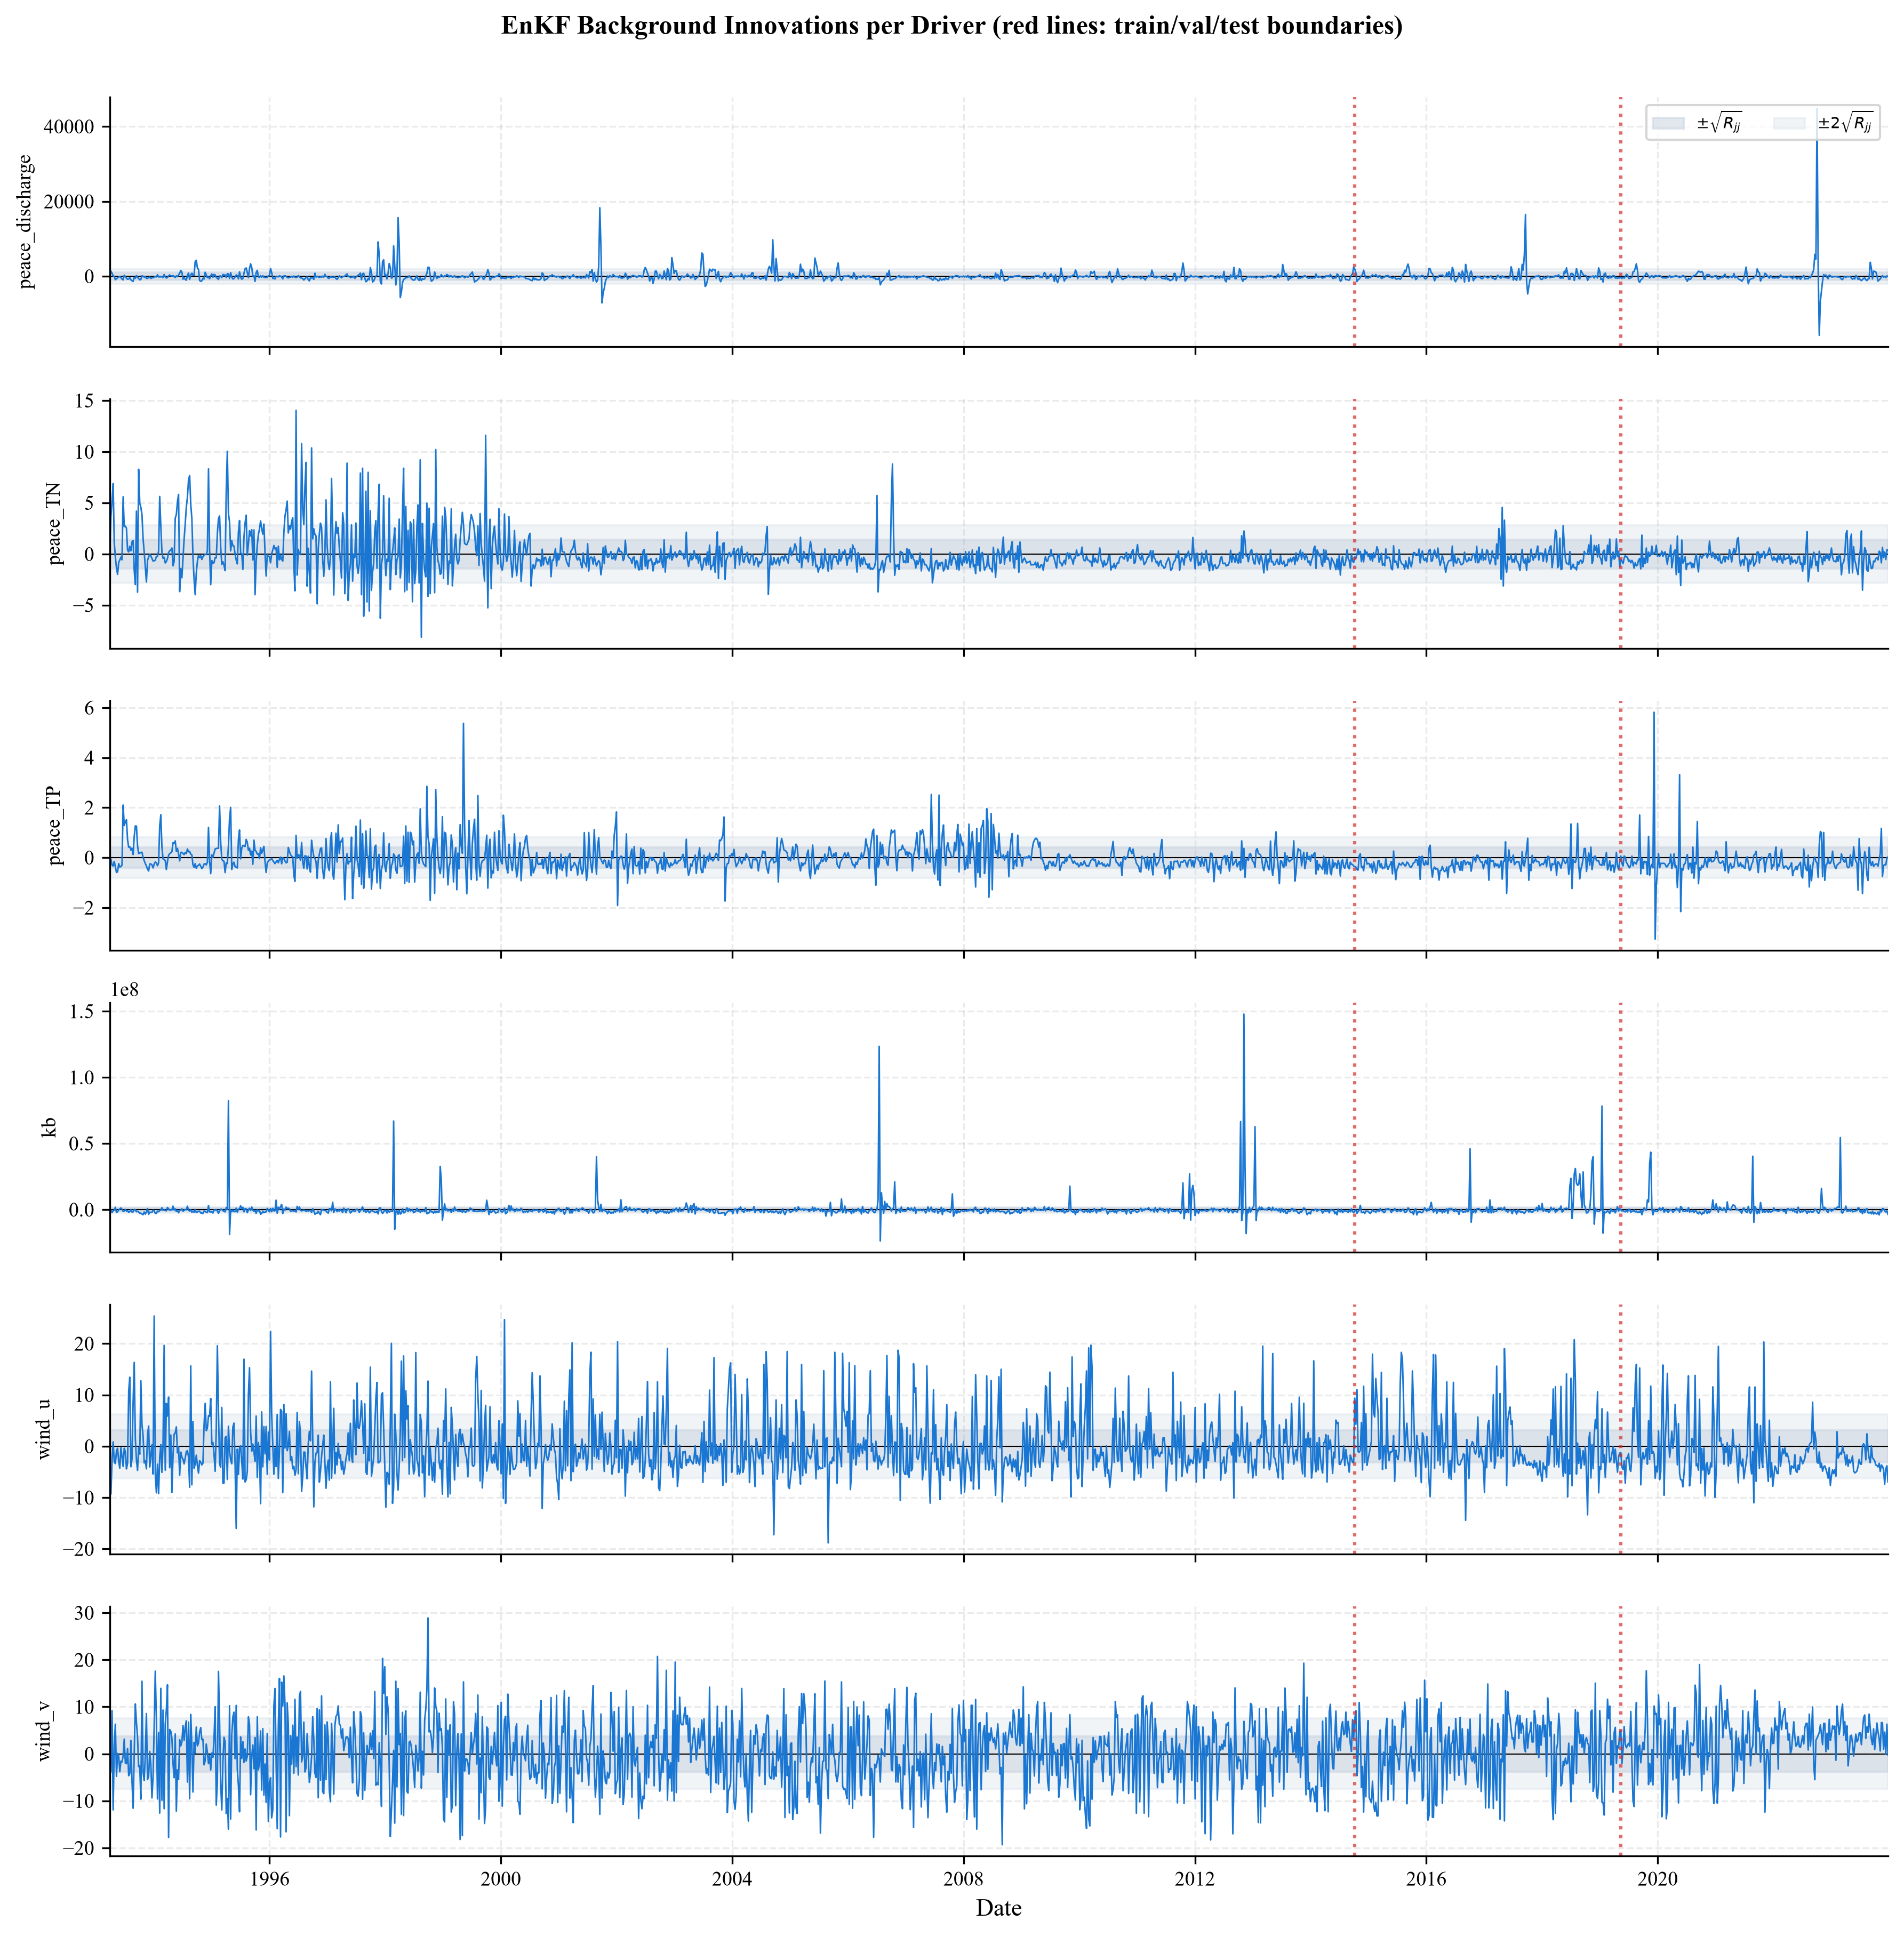

  saved output_refactored/enkf_decomposition\Table4a_innovation_summary.csv
  Innovation magnitude per driver


,driver,sqrt_R_jj,innovation_rmse,innovation_bias,rmse_over_sqrtR,n_assimilations
0,peace_discharge,1.016670e+03,1.766502e+03,31.291085,1.737537,1605
1,peace_TN,1.414850e+00,1.792235e+00,-0.106354,1.266731,1605
2,peace_TP,4.094827e-01,5.660703e-01,-0.062162,1.382403,1605
3,kb,1.124980e+06,7.711528e+06,208618.215595,6.854816,1605
4,wind_u,3.104521e+00,6.010867e+00,-0.151006,1.936166,1605
5,wind_v,3.755503e+00,7.124939e+00,0.516040,1.897200,1605


In [6]:
dates = full_df.index
fig, axes = plt.subplots(len(state_vars), 1, figsize=(12, 2.0 * len(state_vars)),
                         sharex=True)
if len(state_vars) == 1:
    axes = [axes]

for ax, j, var in zip(axes, range(len(state_vars)), state_vars):
    series = result["innovations_background"][:, j]
    sigma_R = float(np.sqrt(R_diag[j]))
    ax.axhline(0, color="black", lw=0.5)
    ax.axhspan(-sigma_R, sigma_R, color="#cbd5e1", alpha=0.55, label=r"$\pm\sqrt{R_{jj}}$")
    ax.axhspan(-2 * sigma_R, 2 * sigma_R, color="#cbd5e1", alpha=0.25, label=r"$\pm 2\sqrt{R_{jj}}$")
    ax.plot(dates, series, color="#1976D2", lw=0.7)
    ax.axvline(dates[n_train], color="#D32F2F", linestyle=":", alpha=0.7)
    ax.axvline(dates[n_train + n_val], color="#D32F2F", linestyle=":", alpha=0.7)
    ax.set_ylabel(var, fontsize=9)
    ax.grid(alpha=0.25, linestyle="--")
    if j == 0:
        ax.legend(loc="upper right", fontsize=7, ncol=2, frameon=True)
    ax.set_xlim(dates[0], dates[-1])

axes[-1].set_xlabel("Date")
fig.suptitle("EnKF Background Innovations per Driver (red lines: train/val/test boundaries)",
             fontweight="bold", y=1.005)
plt.tight_layout()
savefig(fig, "Fig4a_innovations_time_series")
plt.show()

# Summary table
rows = []
for j, var in enumerate(state_vars):
    d = result["innovations_background"][:, j]
    d = d[~np.isnan(d)]
    rmse = float(np.sqrt(np.mean(d ** 2))) if len(d) else np.nan
    bias = float(d.mean()) if len(d) else np.nan
    rows.append({
        "driver": var,
        "sqrt_R_jj": float(np.sqrt(R_diag[j])),
        "innovation_rmse": rmse,
        "innovation_bias": bias,
        "rmse_over_sqrtR": rmse / max(float(np.sqrt(R_diag[j])), 1e-12),
        "n_assimilations": int(len(d)),
    })
innovation_summary = pd.DataFrame(rows)
save_table(innovation_summary, "Table4a_innovation_summary.csv",
           "Innovation magnitude per driver")


## Kalman gain over time

`K_jj` is the per-driver weight the analysis places on the observation
(vs. the forecast prior). With the configured notebook-01 propagator, currently
`SeasonalAR1`, the forecast covariance is generated by the fitted seasonal state
model plus its residual covariance `Q_matrix`. There is therefore no single
random-walk Riccati steady-state reference. The table below reports empirical
gain summaries and a one-step diagonal reference `Q_jj / (Q_jj + R_jj)` for scale.

  saved output_refactored/enkf_decomposition\Fig4b_kalman_gain_time_series.png
  saved output_refactored/enkf_decomposition\Fig4b_kalman_gain_time_series.pdf


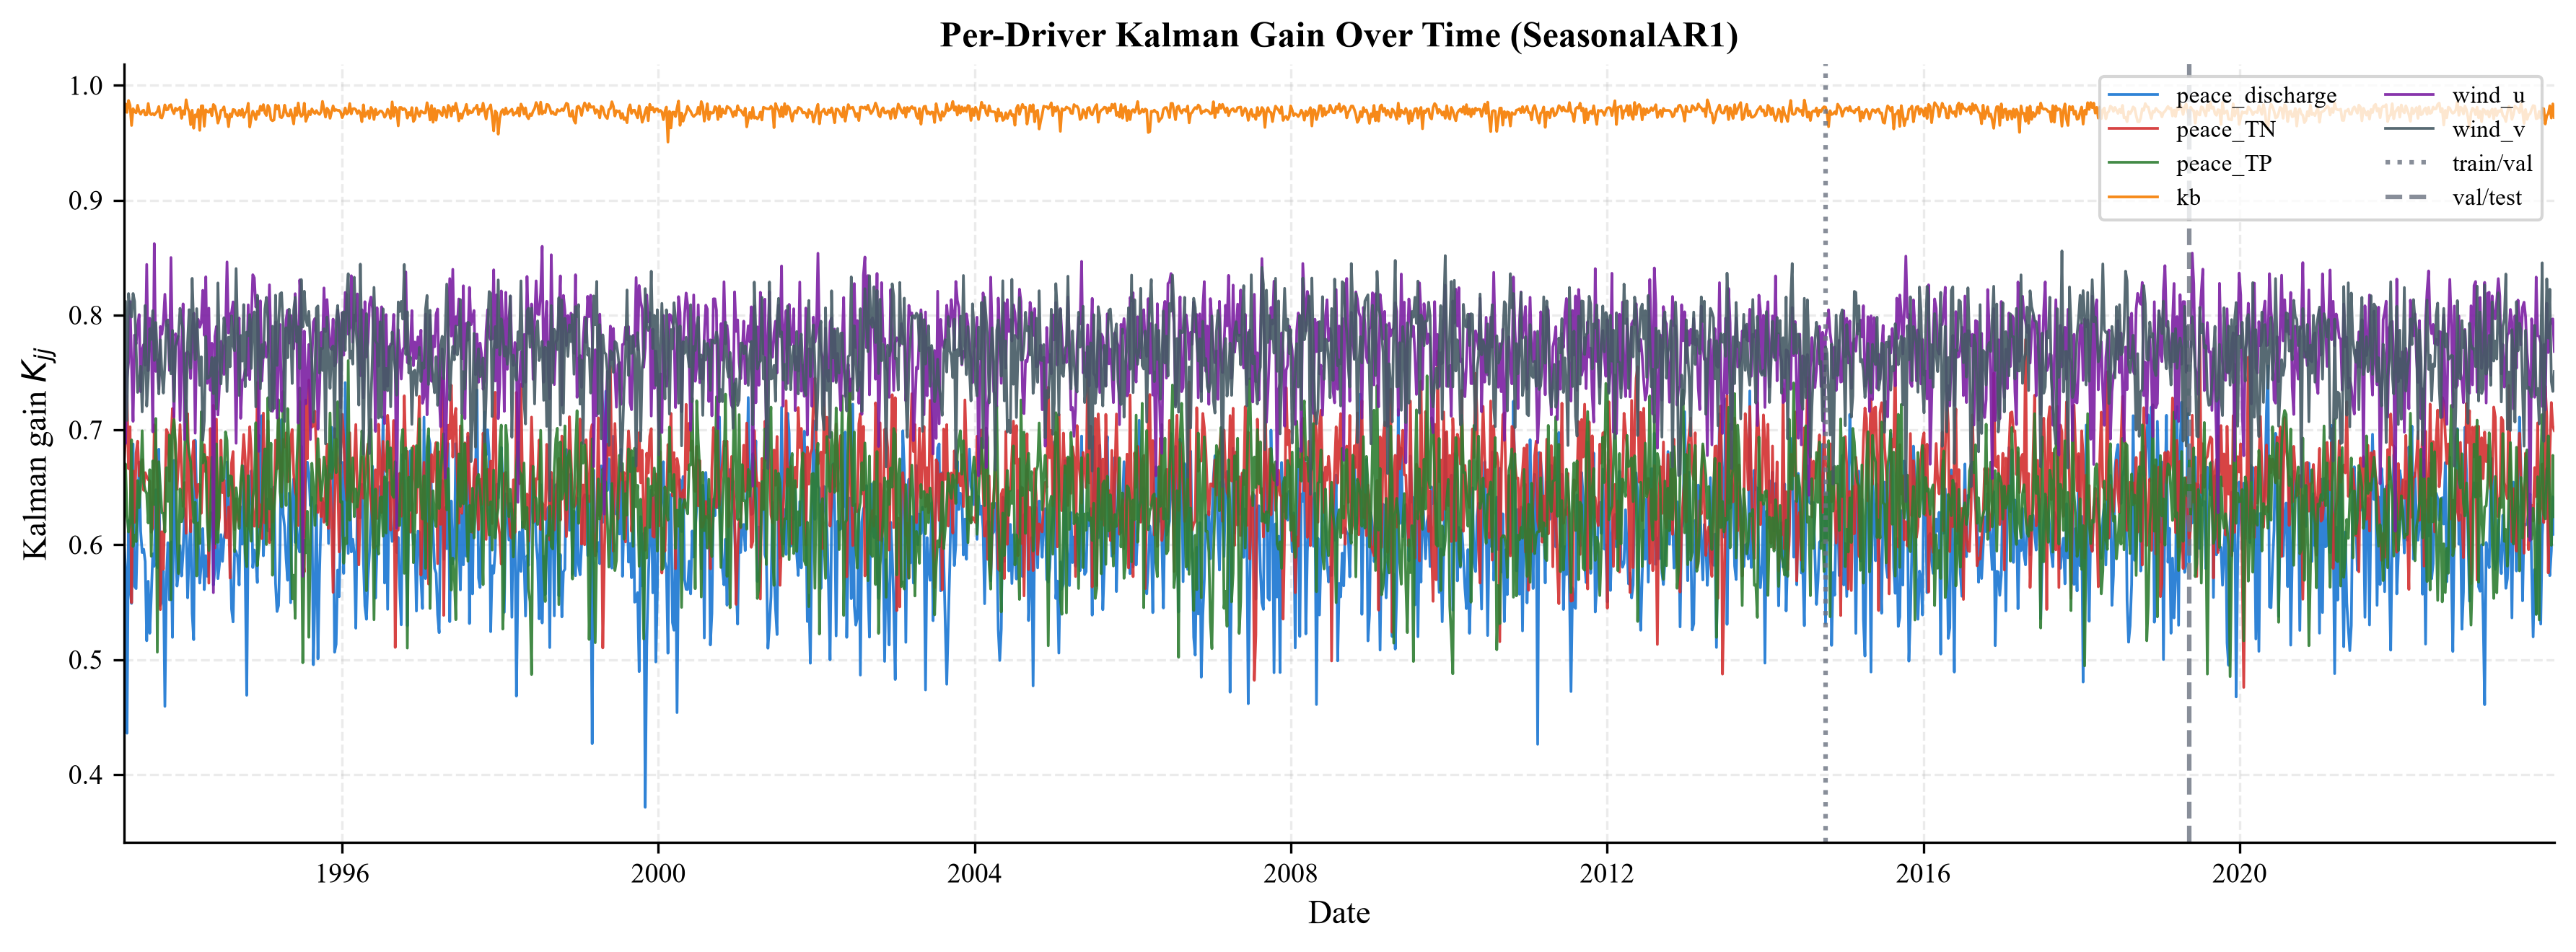

  saved output_refactored/enkf_decomposition\Table4b_kalman_gain_summary.csv
  Kalman gain summary per driver (SeasonalAR1)


,driver,mean_gain_empirical,median_gain_empirical,min_gain_empirical,max_gain_empirical,one_step_qr_gain_reference
0,peace_discharge,0.609120,0.612812,0.371538,0.755794,0.579790
1,peace_TN,0.652233,0.654565,0.475928,0.782112,0.671025
2,peace_TP,0.634376,0.636556,0.485312,0.760483,0.649738
3,kb,0.976906,0.977527,0.950689,0.987507,0.979269
4,wind_u,0.770192,0.774794,0.558411,0.862248,0.793847
5,wind_v,0.766180,0.769476,0.637687,0.855923,0.788890


In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5))
COLORS_K = ["#1976D2", "#D32F2F", "#2E7D32", "#F57C00", "#7B1FA2", "#455A64", "#C62828"]
for j, var in enumerate(state_vars):
    ax.plot(dates, result["kalman_gain_diag"][:, j], lw=0.9, alpha=0.9,
            label=var, color=COLORS_K[j % len(COLORS_K)])
ax.axvline(dates[n_train], color="#6B7280", linestyle=":", alpha=0.8, label="train/val")
ax.axvline(dates[n_train + n_val], color="#6B7280", linestyle="--", alpha=0.8, label="val/test")
ax.set_xlim(dates[0], dates[-1])
ax.set_xlabel("Date")
ax.set_ylabel(r"Kalman gain $K_{jj}$")
ax.set_title(f"Per-Driver Kalman Gain Over Time ({propagator_name})", fontweight="bold")
ax.legend(frameon=True, loc="upper right", ncol=2, fontsize=8)
ax.grid(alpha=0.25, linestyle="--")
plt.tight_layout()
savefig(fig, "Fig4b_kalman_gain_time_series")
plt.show()

rows = []
for j, var in enumerate(state_vars):
    K = result["kalman_gain_diag"][:, j]
    q = float(Q_diag[j])
    r = float(R_diag[j])
    rows.append({
        "driver": var,
        "mean_gain_empirical": float(K.mean()),
        "median_gain_empirical": float(np.median(K)),
        "min_gain_empirical": float(K.min()),
        "max_gain_empirical": float(K.max()),
        "one_step_qr_gain_reference": float(q / max(q + r, 1e-12)),
    })
gain_summary = pd.DataFrame(rows)
save_table(gain_summary, "Table4b_kalman_gain_summary.csv",
           f"Kalman gain summary per driver ({propagator_name})")


## Variance reduction by assimilation

The trace of the analysis covariance `P^a` relative to the forecast
covariance `P^f` quantifies how much each observation step shrinks the
state uncertainty. Values near 1 mean the EnKF essentially ignored
observations (R dominates); values near 0 mean the observations
dominated (R << P^f).

  saved output_refactored/enkf_decomposition\Fig4c_variance_reduction.png
  saved output_refactored/enkf_decomposition\Fig4c_variance_reduction.pdf


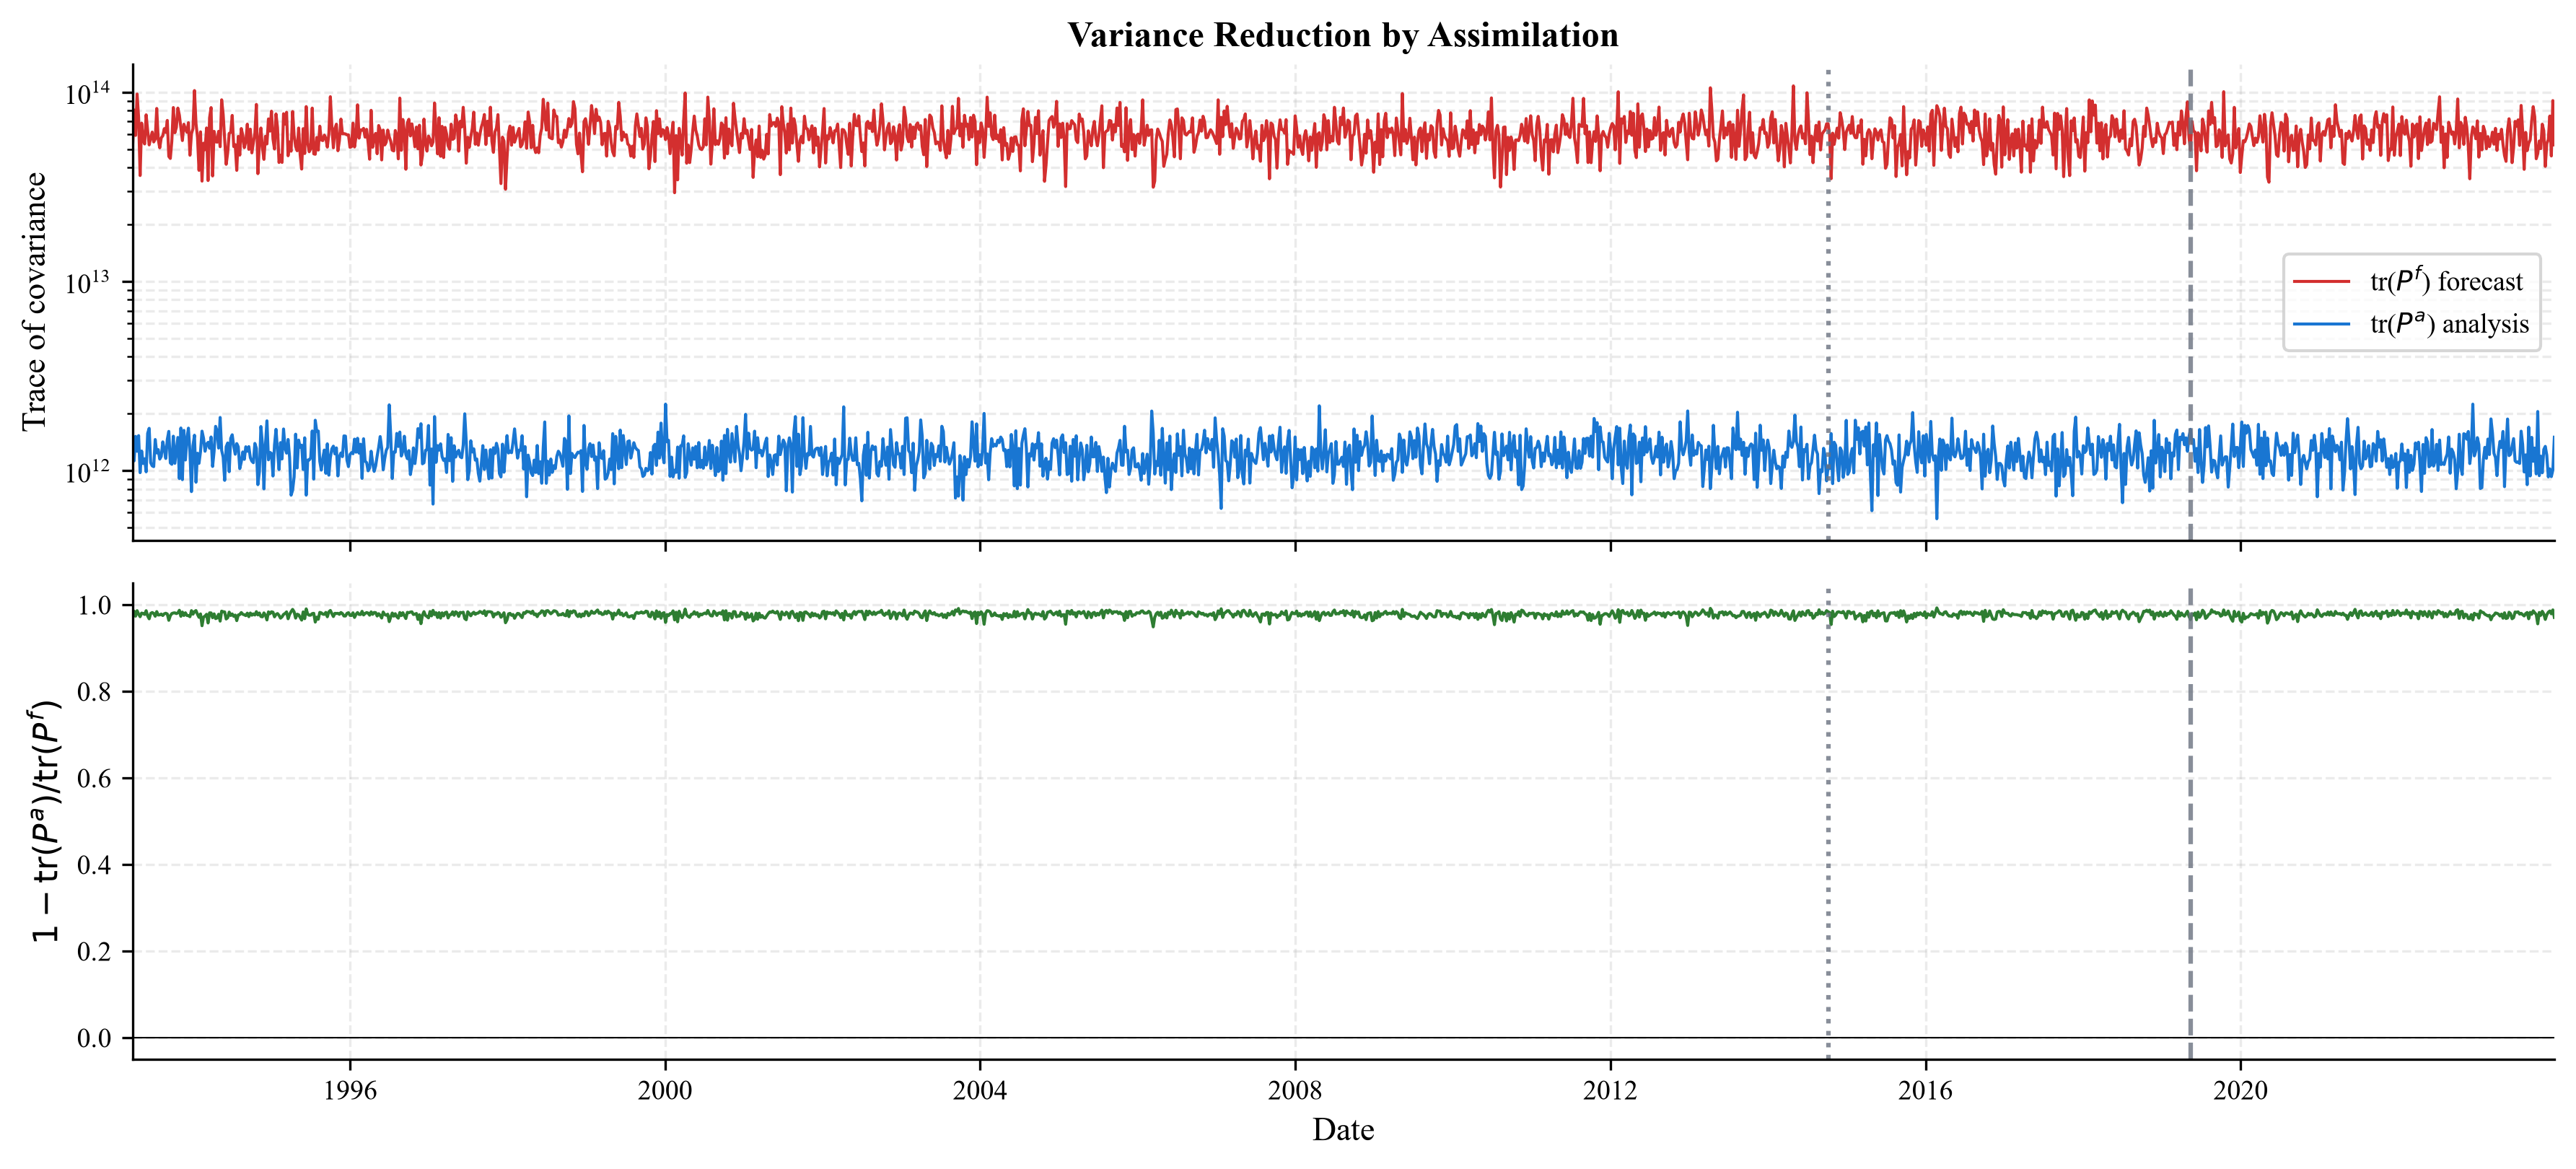

  saved output_refactored/enkf_decomposition\Table4c_variance_reduction_summary.csv
  Variance reduction by split


,mean_reduction_train,mean_reduction_val,mean_reduction_test,mean_reduction_overall
0,0.978577,0.978623,0.978354,0.97855


In [8]:
trace_f = result["P_forecast_diag"].sum(axis=1)
trace_a = result["P_analysis_diag"].sum(axis=1)
reduction = 1.0 - trace_a / np.maximum(trace_f, 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
axes[0].plot(dates, trace_f, color="#D32F2F", lw=1.0, label=r"tr($P^f$) forecast")
axes[0].plot(dates, trace_a, color="#1976D2", lw=1.0, label=r"tr($P^a$) analysis")
axes[0].set_ylabel("Trace of covariance")
axes[0].set_yscale("log")
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.25, linestyle="--", which="both")
axes[0].set_title("Variance Reduction by Assimilation", fontweight="bold")

axes[1].plot(dates, reduction, color="#2E7D32", lw=1.0)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_ylabel(r"$1 - \mathrm{tr}(P^a) / \mathrm{tr}(P^f)$")
axes[1].set_xlabel("Date")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(alpha=0.25, linestyle="--")

for ax in axes:
    ax.axvline(dates[n_train], color="#6B7280", linestyle=":", alpha=0.8)
    ax.axvline(dates[n_train + n_val], color="#6B7280", linestyle="--", alpha=0.8)
    ax.set_xlim(dates[0], dates[-1])

plt.tight_layout()
savefig(fig, "Fig4c_variance_reduction")
plt.show()

reduction_summary = pd.DataFrame([{
    "mean_reduction_train": float(reduction[:n_train].mean()),
    "mean_reduction_val": float(reduction[n_train:n_train + n_val].mean()),
    "mean_reduction_test": float(reduction[n_train + n_val:].mean()),
    "mean_reduction_overall": float(reduction.mean()),
}])
save_table(reduction_summary, "Table4c_variance_reduction_summary.csv",
           "Variance reduction by split")


## Desroziers consistency diagnostics

Desroziers, Berre, Chapnik & Poli (2005, QJRMS) showed two consistency
identities that a well-tuned EnKF must satisfy at steady state:

- **Test 1 (Innovation variance):** `E[d^b (d^b)^T] = HBH^T + R`. With H=I, this
  is `E[d^b (d^b)^T] = P^f + R`. The empirical innovation variance must equal
  the assumed forecast-plus-observation variance.
- **Test 2 (R consistency):** `E[d^a (d^b)^T] = R`. The covariance of analysis
  with background innovations is an empirical estimator of R itself.

Both tests are reported as a ratio of empirical to assumed value with 95%
bootstrap CIs. A consistent EnKF has ratios overlapping 1.0. Ratios > 1
indicate underestimated noise; ratios < 1 indicate overestimated noise.

  saved output_refactored/enkf_decomposition\Table4d_desroziers_consistency.csv
  Desroziers consistency diagnostics (95% bootstrap CIs)


,driver,empirical_innovation_variance,assumed_innovation_variance,innovation_ratio,empirical_R_diag,assumed_R_diag,R_ratio,innovation_ratio_ci_lo,innovation_ratio_ci_hi,R_ratio_ci_lo,R_ratio_ci_hi,innovation_consistent_95,R_consistent_95
0,peace_discharge,3.120528e+06,2.834830e+06,1.100781,1.118774e+06,1.033617e+06,1.082387,0.493525,2.193863,0.536259,1.977426,True,True
1,peace_TN,3.212106e+00,6.738689e+00,0.476666,9.813405e-01,2.001802e+00,0.490229,0.399609,0.561158,0.409416,0.577335,False,False
2,peace_TP,3.204355e-01,5.353155e-01,0.598592,1.027261e-01,1.676761e-01,0.612646,0.492724,0.738678,0.507710,0.746206,False,False
3,kb,5.946766e+13,6.155569e+13,0.966079,1.502794e+12,1.265579e+12,1.187436,0.477801,1.597847,0.561654,2.022536,True,True
4,wind_u,3.613053e+01,4.674373e+01,0.772949,8.063052e+00,9.638048e+00,0.836586,0.704365,0.849624,0.755658,0.922831,False,False
5,wind_v,5.076476e+01,6.699124e+01,0.757782,1.153845e+01,1.410380e+01,0.818109,0.709043,0.810623,0.764268,0.876941,False,False


  saved output_refactored/enkf_decomposition\Fig4d_desroziers_consistency.png
  saved output_refactored/enkf_decomposition\Fig4d_desroziers_consistency.pdf


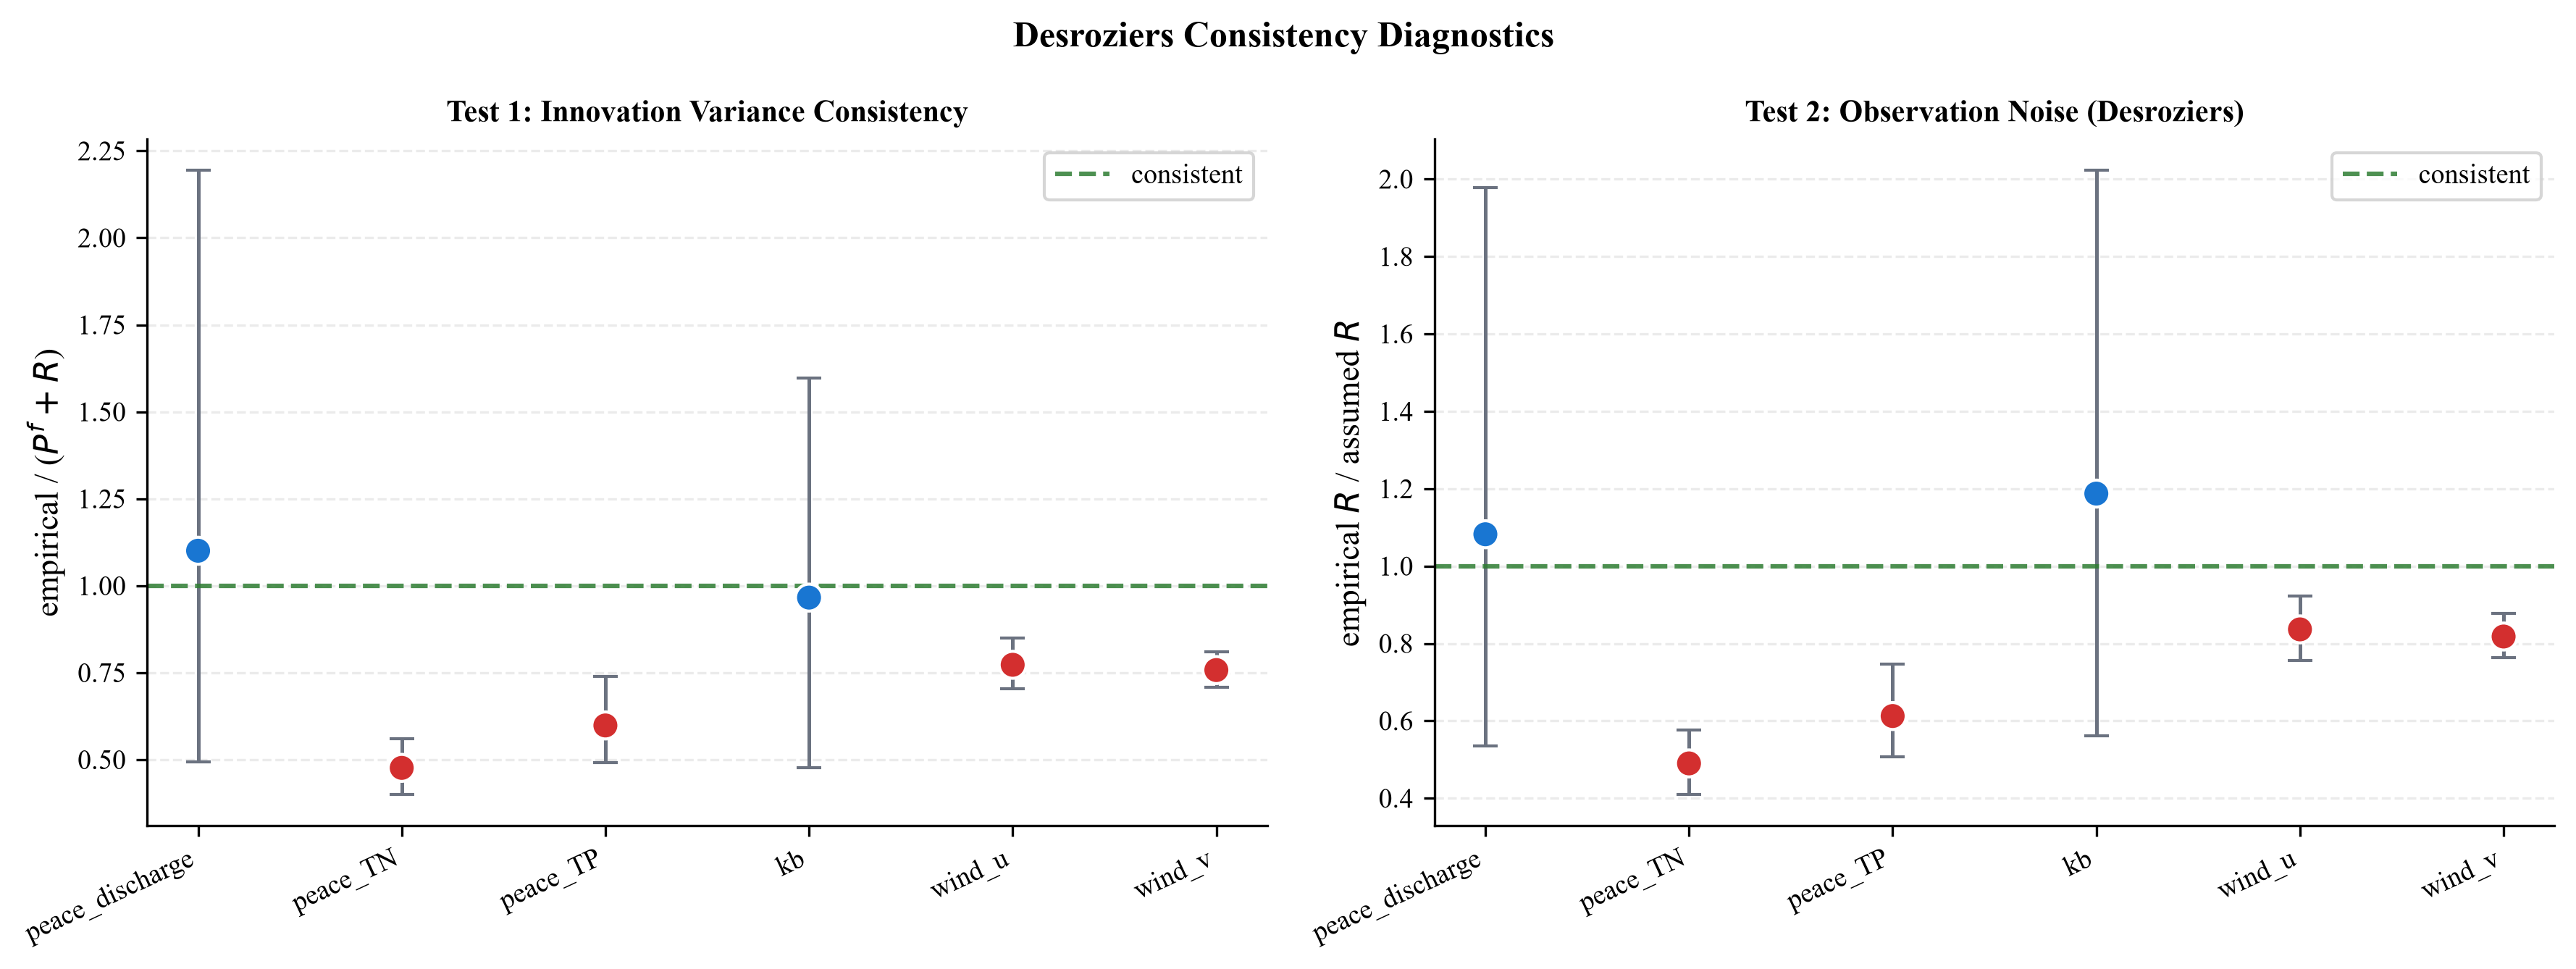


Interpretation:
- Blue marker + CI overlapping 1.0 -> noise specification is consistent with empirical innovations.
- Red marker -> Q or R needs adjustment; see notebook 01 estimate_enkf_noise() configuration.


In [9]:
valid = result["obs_used_mask"]
d_b = result["innovations_background"][valid]
d_a = result["innovations_analysis"][valid]
P_f_valid = result["P_forecast_diag"][valid]
n_valid = len(d_b)
n_drivers = len(state_vars)

# Empirical estimators (Desroziers)
emp_inn_cov = (d_b.T @ d_b) / n_valid
emp_R_cov = (d_a.T @ d_b) / n_valid
mean_P_f_diag = P_f_valid.mean(axis=0)

rows = []
for j, var in enumerate(state_vars):
    emp_inn_var = float(emp_inn_cov[j, j])
    assumed_inn_var = float(mean_P_f_diag[j] + R_diag[j])
    rows.append({
        "driver": var,
        "empirical_innovation_variance": emp_inn_var,
        "assumed_innovation_variance": assumed_inn_var,
        "innovation_ratio": emp_inn_var / max(assumed_inn_var, 1e-12),
        "empirical_R_diag": float(emp_R_cov[j, j]),
        "assumed_R_diag": float(R_diag[j]),
        "R_ratio": float(emp_R_cov[j, j]) / max(float(R_diag[j]), 1e-12),
    })
desroziers = pd.DataFrame(rows)

# Bootstrap CIs (n_boot=2000)
N_BOOT = 2000
rng = np.random.default_rng(SEED)
inn_ratio_boots = np.zeros((n_drivers, N_BOOT))
R_ratio_boots = np.zeros((n_drivers, N_BOOT))
for b in range(N_BOOT):
    idx = rng.choice(n_valid, n_valid, replace=True)
    db_b = d_b[idx]
    da_b = d_a[idx]
    Pf_b = P_f_valid[idx]
    for j in range(n_drivers):
        emp_inn = float(np.mean(db_b[:, j] ** 2))
        emp_R = float(np.mean(da_b[:, j] * db_b[:, j]))
        denom_inn = max(float(Pf_b[:, j].mean() + R_diag[j]), 1e-12)
        inn_ratio_boots[j, b] = emp_inn / denom_inn
        R_ratio_boots[j, b] = emp_R / max(float(R_diag[j]), 1e-12)

desroziers["innovation_ratio_ci_lo"] = np.percentile(inn_ratio_boots, 2.5, axis=1)
desroziers["innovation_ratio_ci_hi"] = np.percentile(inn_ratio_boots, 97.5, axis=1)
desroziers["R_ratio_ci_lo"] = np.percentile(R_ratio_boots, 2.5, axis=1)
desroziers["R_ratio_ci_hi"] = np.percentile(R_ratio_boots, 97.5, axis=1)
desroziers["innovation_consistent_95"] = (desroziers["innovation_ratio_ci_lo"] <= 1.0) & (desroziers["innovation_ratio_ci_hi"] >= 1.0)
desroziers["R_consistent_95"] = (desroziers["R_ratio_ci_lo"] <= 1.0) & (desroziers["R_ratio_ci_hi"] >= 1.0)

save_table(desroziers, "Table4d_desroziers_consistency.csv",
           "Desroziers consistency diagnostics (95% bootstrap CIs)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(n_drivers)
inn_vals = desroziers["innovation_ratio"].values
inn_err = np.vstack([inn_vals - desroziers["innovation_ratio_ci_lo"].values,
                     desroziers["innovation_ratio_ci_hi"].values - inn_vals])
colors_inn = np.where(desroziers["innovation_consistent_95"].values, "#1976D2", "#D32F2F")
axes[0].errorbar(x, inn_vals, yerr=inn_err, fmt="none", ecolor="#6B7280", elinewidth=1.2, capsize=4)
axes[0].scatter(x, inn_vals, c=colors_inn, s=80, edgecolor="white", zorder=3)
axes[0].axhline(1.0, color="#2E7D32", linestyle="--", alpha=0.85, label="consistent")
axes[0].set_xticks(x); axes[0].set_xticklabels(state_vars, rotation=25, ha="right")
axes[0].set_ylabel(r"empirical / ($P^f + R$)")
axes[0].set_title("Test 1: Innovation Variance Consistency", fontweight="bold", fontsize=10)
axes[0].grid(axis="y", alpha=0.25, linestyle="--")
axes[0].legend(frameon=True)

R_vals = desroziers["R_ratio"].values
R_err = np.vstack([R_vals - desroziers["R_ratio_ci_lo"].values,
                   desroziers["R_ratio_ci_hi"].values - R_vals])
colors_R = np.where(desroziers["R_consistent_95"].values, "#1976D2", "#D32F2F")
axes[1].errorbar(x, R_vals, yerr=R_err, fmt="none", ecolor="#6B7280", elinewidth=1.2, capsize=4)
axes[1].scatter(x, R_vals, c=colors_R, s=80, edgecolor="white", zorder=3)
axes[1].axhline(1.0, color="#2E7D32", linestyle="--", alpha=0.85, label="consistent")
axes[1].set_xticks(x); axes[1].set_xticklabels(state_vars, rotation=25, ha="right")
axes[1].set_ylabel(r"empirical $R$ / assumed $R$")
axes[1].set_title("Test 2: Observation Noise (Desroziers)", fontweight="bold", fontsize=10)
axes[1].grid(axis="y", alpha=0.25, linestyle="--")
axes[1].legend(frameon=True)

fig.suptitle("Desroziers Consistency Diagnostics", fontweight="bold")
plt.tight_layout()
savefig(fig, "Fig4d_desroziers_consistency")
plt.show()

print("\nInterpretation:")
print("- Blue marker + CI overlapping 1.0 -> noise specification is consistent with empirical innovations.")
print("- Red marker -> Q or R needs adjustment; see notebook 01 estimate_enkf_noise() configuration.")


## Joint Q/R calibration across all drivers

This optional diagnostic explores whether the fitted `Q_matrix` and `R_diag` are
empirically consistent with the innovation products. The main model path above
already uses the configured notebook-01 propagator. This calibration section is
retained as an exploratory sensitivity check and does not feed notebook 04b or
the main LSTM-EnKF predictions.

At each iteration, every multiplier is updated by its channel's Desroziers ratio
raised to a damping power (0.5). Convergence means all consistency ratios are
within 15% of 1.0.


In [10]:
def enkf_calibrated(observations, Q_base_diag, R_base_diag,
                    kb_idx, alpha_kb, Q_kb_floor,
                    Q_inflation, R_inflation,
                    n_enkf=50, seed=42):
    """EnKF with state-dependent Q on the kb channel and per-channel Q/R
    inflation on all other channels.

    For j == kb_idx: Q[j](t) = max(alpha_kb * x_kb(t-1)**2, Q_kb_floor)
    For j != kb_idx: Q[j]    = Q_inflation[j] * Q_base_diag[j]   (constant)
    For all j:       R[j]    = R_inflation[j] * R_base_diag[j]   (constant)
    """
    rng = np.random.default_rng(seed)
    T, n = observations.shape
    Q_base = np.asarray(Q_base_diag, dtype=float).copy()
    R_eff = np.asarray(R_inflation, dtype=float) * np.asarray(R_base_diag, dtype=float)
    R = np.diag(R_eff)

    valid_mask = ~np.any(np.isnan(observations), axis=1)
    if not valid_mask.any():
        raise ValueError("No valid observations.")
    first_valid_idx = int(np.argmax(valid_mask))
    x0 = observations[first_valid_idx]
    ensemble = x0[None, :] + rng.multivariate_normal(np.zeros(n), np.diag(Q_base), size=n_enkf)

    members = np.zeros((n_enkf, T, n), dtype=np.float64)
    x_f_mean = np.zeros((T, n)); x_a_mean = np.zeros((T, n))
    d_b = np.full((T, n), np.nan); d_a = np.full((T, n), np.nan)
    K_diag = np.zeros((T, n))
    P_f_diag = np.zeros((T, n)); P_a_diag = np.zeros((T, n))
    Q_kb_track = np.zeros(T)
    obs_used = np.zeros(T, dtype=bool)

    for t in range(T):
        # Per-channel Q at this step; kb is state-dependent, others are inflation * base
        Q_diag_t = Q_inflation * Q_base
        if t == 0:
            Q_kb_t = Q_base[kb_idx]
        else:
            kb_prev = float(ensemble.mean(axis=0)[kb_idx])
            Q_kb_t = max(alpha_kb * kb_prev**2, Q_kb_floor)
        Q_diag_t[kb_idx] = Q_kb_t
        Q_kb_track[t] = Q_kb_t
        Q = np.diag(Q_diag_t)

        if t == 0:
            ens_f = ensemble.copy()
        else:
            w = rng.multivariate_normal(np.zeros(n), Q, size=n_enkf)
            ens_f = ensemble + w

        xf = ens_f.mean(axis=0)
        Pf = np.cov(ens_f.T) if n_enkf > 1 else np.zeros((n, n))
        x_f_mean[t] = xf; P_f_diag[t] = np.diag(Pf)

        y = observations[t]
        if np.any(np.isnan(y)):
            ens_a = ens_f; xa = xf; Pa = Pf
        else:
            d_b[t] = y - xf
            obs_used[t] = True
            S = Pf + R
            try:
                K = np.linalg.solve(S.T, Pf.T).T
            except np.linalg.LinAlgError:
                K = Pf @ np.linalg.pinv(S)
            K_diag[t] = np.diag(K)
            v = rng.multivariate_normal(np.zeros(n), R, size=n_enkf)
            ens_a = ens_f + ((y[None, :] + v) - ens_f) @ K.T
            xa = ens_a.mean(axis=0)
            Pa = np.cov(ens_a.T) if n_enkf > 1 else np.zeros((n, n))
            d_a[t] = y - xa

        x_a_mean[t] = xa; P_a_diag[t] = np.diag(Pa)
        members[:, t, :] = ens_a
        ensemble = ens_a

    return {
        "members": members,
        "x_forecast_mean": x_f_mean, "x_analysis_mean": x_a_mean,
        "innovations_background": d_b, "innovations_analysis": d_a,
        "kalman_gain_diag": K_diag,
        "P_forecast_diag": P_f_diag, "P_analysis_diag": P_a_diag,
        "obs_used_mask": obs_used,
        "Q_kb_track": Q_kb_track,
        "R_eff": R_eff,
    }


In [11]:
# Identify kb channel
kb_candidates = [i for i, v in enumerate(state_vars)
                 if any(k in v.lower() for k in ("kb", "brevis", "karenia"))]
if not kb_candidates:
    raise RuntimeError(f"kb channel not found in state_vars={state_vars}")
KB_IDX = kb_candidates[0]
n_drivers = len(state_vars)
print(f"kb channel: state_vars[{KB_IDX}] = {state_vars[KB_IDX]!r}\n")

# Initial alpha_kb so that alpha * mean(kb**2) approx equals original constant Q_kb
kb_valid = observations[~np.isnan(observations[:, KB_IDX]), KB_IDX]
alpha_kb = float(Q_diag[KB_IDX] / max(np.mean(kb_valid ** 2), 1e-12))
Q_kb_floor = float(Q_diag[KB_IDX] * 0.01)

# Per-channel inflation factors (start at 1 = no inflation)
Q_inflation = np.ones(n_drivers)
R_inflation = np.ones(n_drivers)

DAMPING = 0.5
N_CAL_ITER = 10
TOL = 0.15  # |ratio - 1| < TOL on all channels and both tests -> converged

cal_history = []
for it in range(N_CAL_ITER):
    res = enkf_calibrated(
        observations, Q_diag, R_diag, KB_IDX,
        alpha_kb=alpha_kb, Q_kb_floor=Q_kb_floor,
        Q_inflation=Q_inflation, R_inflation=R_inflation,
        n_enkf=N_ENKF_CFG, seed=SEED,
    )
    valid_it = res["obs_used_mask"]
    db = res["innovations_background"][valid_it]
    da = res["innovations_analysis"][valid_it]
    Pf_it = res["P_forecast_diag"][valid_it]
    R_eff_it = res["R_eff"]

    inn_ratios = np.zeros(n_drivers)
    R_ratios = np.zeros(n_drivers)
    for j in range(n_drivers):
        emp_inn = float(np.mean(db[:, j] ** 2))
        emp_R = float(np.mean(da[:, j] * db[:, j]))
        assumed_inn = float(Pf_it[:, j].mean() + R_eff_it[j])
        inn_ratios[j] = emp_inn / max(assumed_inn, 1e-12)
        R_ratios[j] = emp_R / max(R_eff_it[j], 1e-12)

    row = {"iter": it, "alpha_kb": alpha_kb}
    for j in range(n_drivers):
        row[f"Q_mult_{state_vars[j]}"] = (alpha_kb if j == KB_IDX else float(Q_inflation[j]))
        row[f"R_mult_{state_vars[j]}"] = float(R_inflation[j])
        row[f"inn_ratio_{state_vars[j]}"] = inn_ratios[j]
        row[f"R_ratio_{state_vars[j]}"] = R_ratios[j]
    cal_history.append(row)

    max_dev = max(np.max(np.abs(inn_ratios - 1.0)),
                  np.max(np.abs(R_ratios - 1.0)))
    print(f"  iter {it}: max |ratio - 1| = {max_dev:.3f}")
    print("    inn_ratios: " + ", ".join(f"{state_vars[j]}={inn_ratios[j]:.2f}"
                                          for j in range(n_drivers)))
    print("    R_ratios  : " + ", ".join(f"{state_vars[j]}={R_ratios[j]:.2f}"
                                          for j in range(n_drivers)))
    if max_dev < TOL:
        print(f"  converged at iter {it}")
        break

    # Joint damped multiplicative update
    for j in range(n_drivers):
        if j == KB_IDX:
            alpha_kb *= inn_ratios[j] ** DAMPING
        else:
            Q_inflation[j] *= inn_ratios[j] ** DAMPING
        R_inflation[j] *= R_ratios[j] ** DAMPING

cal_df = pd.DataFrame(cal_history)
save_table(cal_df, "Table4e_full_calibration_history.csv",
           "Joint Q/R calibration across all drivers (iterative Desroziers)")
result_sd = res


kb channel: state_vars[3] = 'kb'

  iter 0: max |ratio - 1| = 12.621
    inn_ratios: peace_discharge=1.11, peace_TN=0.46, peace_TP=0.57, kb=1.85, wind_u=1.00, wind_v=0.96
    R_ratios  : peace_discharge=1.19, peace_TN=0.47, peace_TP=0.61, kb=13.62, wind_u=1.08, wind_v=1.04
  iter 1: max |ratio - 1| = 4.632
    inn_ratios: peace_discharge=1.03, peace_TN=0.65, peace_TP=0.73, kb=1.50, wind_u=0.98, wind_v=0.96
    R_ratios  : peace_discharge=1.10, peace_TN=0.67, peace_TP=0.77, kb=5.63, wind_u=1.06, wind_v=1.04
  iter 2: max |ratio - 1| = 1.968
    inn_ratios: peace_discharge=1.00, peace_TN=0.79, peace_TP=0.83, kb=1.25, wind_u=0.97, wind_v=0.96
    R_ratios  : peace_discharge=1.07, peace_TN=0.82, peace_TP=0.88, kb=2.97, wind_u=1.05, wind_v=1.04
  iter 3: max |ratio - 1| = 0.908
    inn_ratios: peace_discharge=0.98, peace_TN=0.88, peace_TP=0.90, kb=1.05, wind_u=0.97, wind_v=0.96
    R_ratios  : peace_discharge=1.05, peace_TN=0.91, peace_TP=0.95, kb=1.91, wind_u=1.05, wind_v=1.04
  iter 4: ma

,iter,alpha_kb,Q_mult_peace_discharge,R_mult_peace_discharge,inn_ratio_peace_discharge,R_ratio_peace_discharge,Q_mult_peace_TN,R_mult_peace_TN,inn_ratio_peace_TN,R_ratio_peace_TN,...,inn_ratio_kb,R_ratio_kb,Q_mult_wind_u,R_mult_wind_u,inn_ratio_wind_u,R_ratio_wind_u,Q_mult_wind_v,R_mult_wind_v,inn_ratio_wind_v,R_ratio_wind_v
0,0,0.919896,1.000000,1.000000,1.105357,1.185010,1.000000,1.000000,0.456219,0.473096,...,1.852282,13.621383,1.000000,1.000000,0.995771,1.077492,1.000000,1.000000,0.958284,1.043002
1,1,1.251965,1.051359,1.088581,1.025093,1.097348,0.675439,0.687820,0.648956,0.673314,...,1.504754,5.631516,0.997883,1.038023,0.979329,1.059228,0.978920,1.021275,0.958489,1.039906
2,2,1.535766,1.064469,1.140337,0.996688,1.065088,0.544119,0.564395,0.788730,0.818677,...,1.249827,2.967568,0.987516,1.068321,0.973249,1.052040,0.958386,1.041453,0.961033,1.040917
3,3,1.716920,1.062705,1.176863,0.983778,1.048945,0.483235,0.510669,0.875935,0.909710,...,1.047733,1.907741,0.974218,1.095766,0.970595,1.048218,0.939528,1.062545,0.963309,1.041895
4,4,1.757420,1.054050,1.205320,0.977767,1.040224,0.452266,0.487070,0.925562,0.961361,...,0.933406,1.456063,0.959787,1.121873,0.969334,1.045792,0.922131,1.084575,0.964755,1.042072
5,5,1.697895,1.042267,1.229322,0.975094,1.035200,0.435108,0.477567,0.952430,0.989016,...,0.881419,1.244794,0.944956,1.147272,0.968702,1.044005,0.905735,1.107155,0.965595,1.041607
6,6,1.594050,1.029206,1.250771,0.974055,1.032047,0.424633,0.474937,0.966654,1.003367,...,0.865038,1.140449,0.930051,1.172243,0.968349,1.042533,0.890017,1.129953,0.966063,1.040793


  saved output_refactored/enkf_decomposition\Table4f_full_calibration_comparison.csv
  Full Desroziers calibration: before vs after, all channels


,driver,inn_ratio_before,inn_ratio_after,R_ratio_before,R_ratio_after,Q_multiplier,R_multiplier,inn_after_ci_lo,inn_after_ci_hi,R_after_ci_lo,R_after_ci_hi,inn_consistent_95,R_consistent_95
0,peace_discharge,1.100781,0.974055,1.082387,1.032047,1.029206,1.250771,0.486739,1.792394,0.518918,1.898367,True,True
1,peace_TN,0.476666,0.966654,0.490229,1.003367,0.424633,0.474937,0.806655,1.139958,0.839563,1.175608,True,True
2,peace_TP,0.598592,0.963803,0.612646,1.012770,0.524756,0.622223,0.784643,1.196501,0.837676,1.250485,True,True
3,kb,0.966079,0.865038,1.187436,1.140449,1.594050,28.055769,0.422497,1.492204,0.528203,1.907583,True,True
4,wind_u,0.772949,0.968349,0.836586,1.042533,0.930051,1.172243,0.883460,1.061749,0.945542,1.144238,True,True
5,wind_v,0.757782,0.966063,0.818109,1.040793,0.890017,1.129953,0.896178,1.041584,0.966234,1.119052,True,True


  saved output_refactored/enkf_decomposition\Fig4e_full_calibration_comparison.png
  saved output_refactored/enkf_decomposition\Fig4e_full_calibration_comparison.pdf


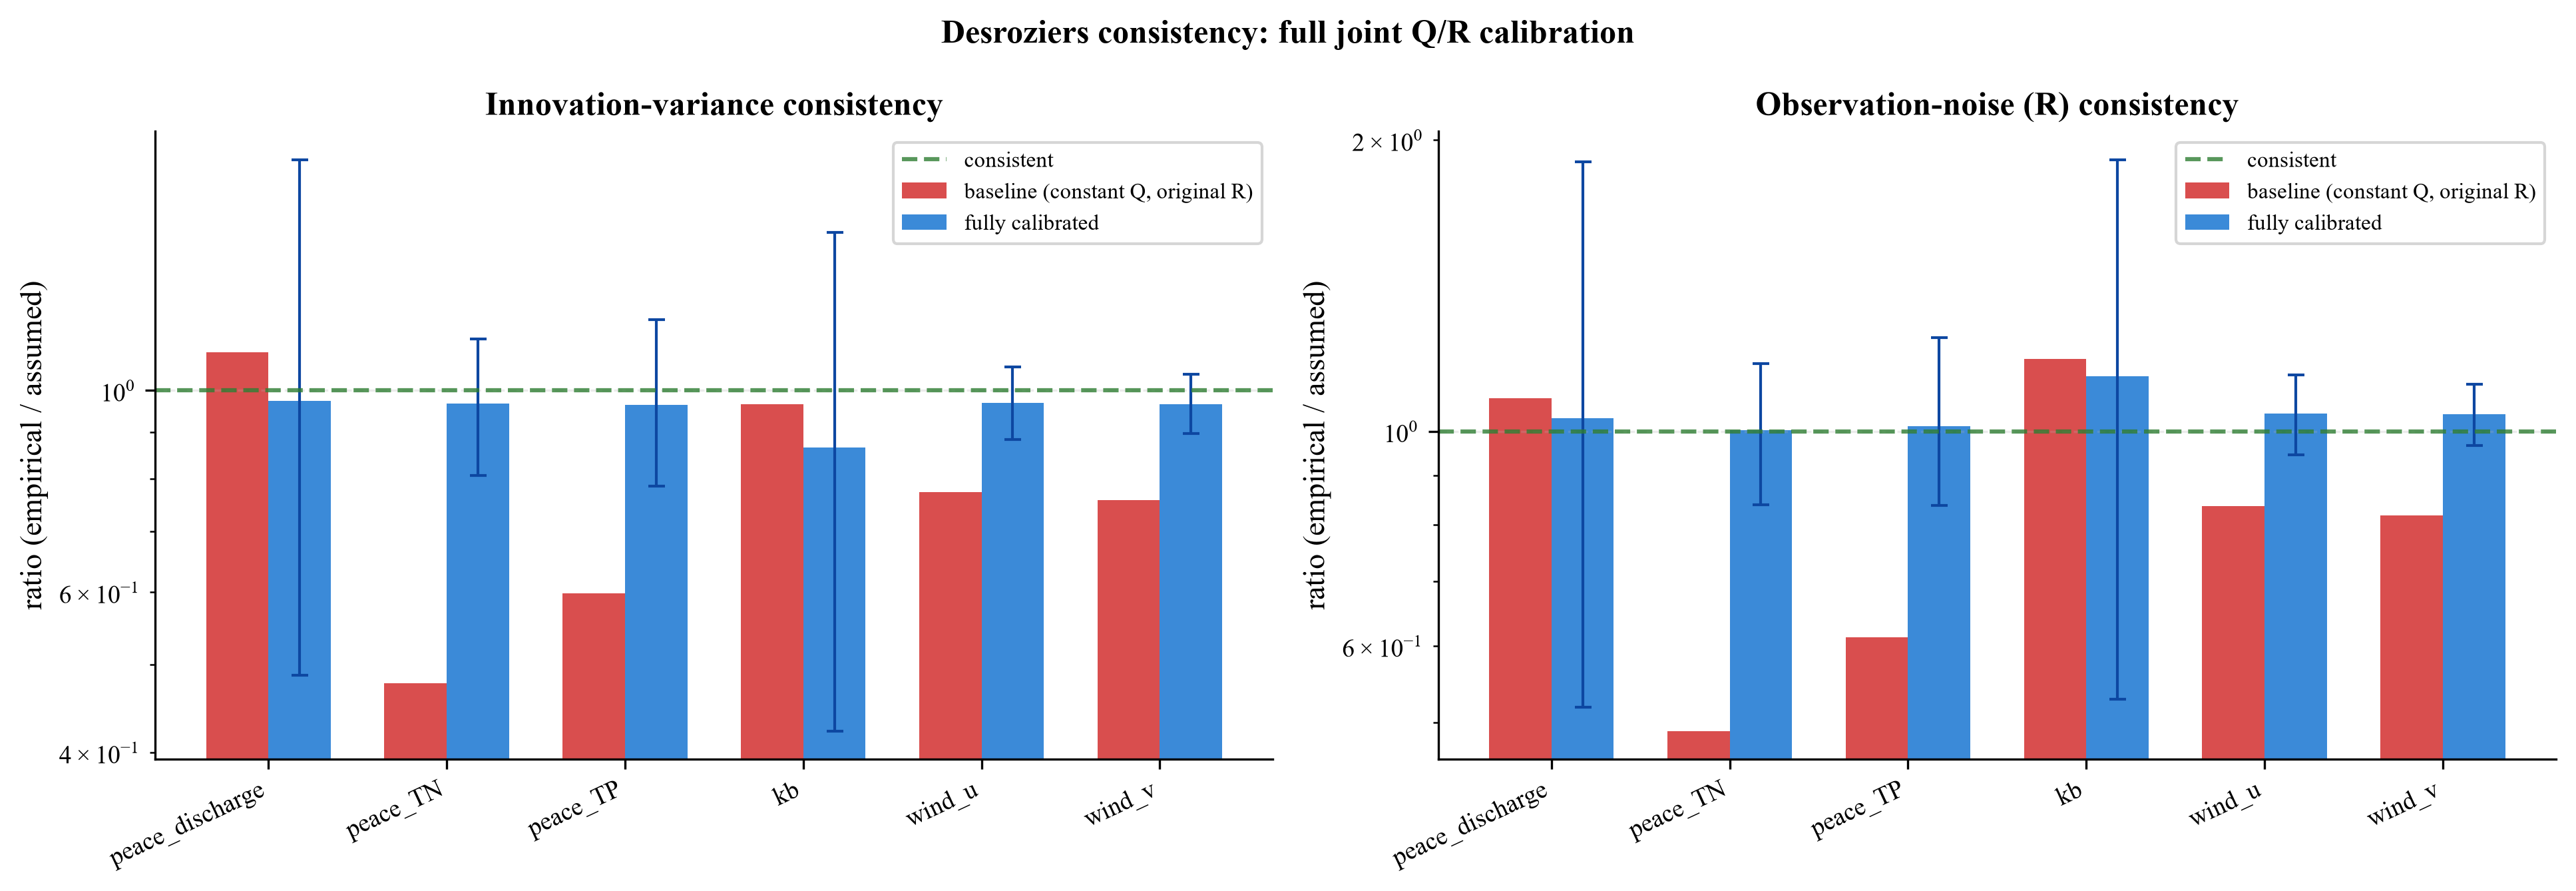


Final calibration multipliers:
         driver  Q_multiplier  R_multiplier  inn_ratio_after  inn_consistent_95  R_ratio_after  R_consistent_95
peace_discharge      1.029206      1.250771         0.974055               True       1.032047             True
       peace_TN      0.424633      0.474937         0.966654               True       1.003367             True
       peace_TP      0.524756      0.622223         0.963803               True       1.012770             True
             kb      1.594050     28.055769         0.865038               True       1.140449             True
         wind_u      0.930051      1.172243         0.968349               True       1.042533             True
         wind_v      0.890017      1.129953         0.966063               True       1.040793             True


In [12]:
valid_sd = result_sd["obs_used_mask"]
d_b_sd = result_sd["innovations_background"][valid_sd]
d_a_sd = result_sd["innovations_analysis"][valid_sd]
P_f_sd = result_sd["P_forecast_diag"][valid_sd]
R_eff_sd = result_sd["R_eff"]
n_valid_sd = len(d_b_sd)

rows_sd = []
for j, var in enumerate(state_vars):
    emp_inn = float(np.mean(d_b_sd[:, j] ** 2))
    emp_R = float(np.mean(d_a_sd[:, j] * d_b_sd[:, j]))
    assumed_inn = float(P_f_sd[:, j].mean() + R_eff_sd[j])
    rows_sd.append({
        "driver": var,
        "inn_ratio_before": float(desroziers.loc[j, "innovation_ratio"]),
        "inn_ratio_after":  emp_inn / max(assumed_inn, 1e-12),
        "R_ratio_before":   float(desroziers.loc[j, "R_ratio"]),
        "R_ratio_after":    emp_R / max(R_eff_sd[j], 1e-12),
        "Q_multiplier":     alpha_kb if j == KB_IDX else float(Q_inflation[j]),
        "R_multiplier":     float(R_inflation[j]),
    })
calib_compare = pd.DataFrame(rows_sd)

# Bootstrap CIs on the post-calibration ratios
rng = np.random.default_rng(SEED)
inn_boots = np.zeros((n_drivers, N_BOOT))
R_boots = np.zeros((n_drivers, N_BOOT))
for b in range(N_BOOT):
    idx = rng.choice(n_valid_sd, n_valid_sd, replace=True)
    db_b = d_b_sd[idx]; da_b = d_a_sd[idx]; Pf_b = P_f_sd[idx]
    for j in range(n_drivers):
        denom = max(float(Pf_b[:, j].mean() + R_eff_sd[j]), 1e-12)
        inn_boots[j, b] = float(np.mean(db_b[:, j] ** 2)) / denom
        R_boots[j, b]   = float(np.mean(da_b[:, j] * db_b[:, j])) / max(R_eff_sd[j], 1e-12)

calib_compare["inn_after_ci_lo"] = np.percentile(inn_boots, 2.5, axis=1)
calib_compare["inn_after_ci_hi"] = np.percentile(inn_boots, 97.5, axis=1)
calib_compare["R_after_ci_lo"]   = np.percentile(R_boots, 2.5, axis=1)
calib_compare["R_after_ci_hi"]   = np.percentile(R_boots, 97.5, axis=1)
calib_compare["inn_consistent_95"] = (
    (calib_compare["inn_after_ci_lo"] <= 1.0) & (calib_compare["inn_after_ci_hi"] >= 1.0))
calib_compare["R_consistent_95"] = (
    (calib_compare["R_after_ci_lo"] <= 1.0) & (calib_compare["R_after_ci_hi"] >= 1.0))

save_table(calib_compare, "Table4f_full_calibration_comparison.csv",
           "Full Desroziers calibration: before vs after, all channels")

# Two-panel before/after for innovation and R ratios
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(n_drivers); w = 0.35
panels = [
    (axes[0], "inn_ratio_before", "inn_ratio_after",
     "Innovation-variance consistency", "inn_after_ci_lo", "inn_after_ci_hi"),
    (axes[1], "R_ratio_before", "R_ratio_after",
     "Observation-noise (R) consistency", "R_after_ci_lo", "R_after_ci_hi"),
]
for ax, before_col, after_col, title, lo, hi in panels:
    ax.bar(x - w/2, calib_compare[before_col].values, w,
           label="baseline (constant Q, original R)", color="#D32F2F", alpha=0.85)
    ax.bar(x + w/2, calib_compare[after_col].values, w,
           label="fully calibrated", color="#1976D2", alpha=0.85)
    err = np.vstack([
        calib_compare[after_col].values - calib_compare[lo].values,
        calib_compare[hi].values - calib_compare[after_col].values,
    ])
    ax.errorbar(x + w/2, calib_compare[after_col].values, yerr=err,
                fmt="none", ecolor="#0D47A1", capsize=3, linewidth=1.0)
    ax.axhline(1.0, color="#2E7D32", linestyle="--", alpha=0.8, label="consistent")
    ax.set_yscale("log")
    ax.set_xticks(x); ax.set_xticklabels(state_vars, rotation=25, ha="right")
    ax.set_ylabel("ratio (empirical / assumed)")
    ax.set_title(title, fontweight="bold")
    ax.legend(frameon=True, fontsize=8)
    ax.grid(axis="y", alpha=0.25, linestyle="--")

fig.suptitle("Desroziers consistency: full joint Q/R calibration", fontweight="bold")
plt.tight_layout()
savefig(fig, "Fig4e_full_calibration_comparison")
plt.show()

print("\nFinal calibration multipliers:")
print(calib_compare[["driver", "Q_multiplier", "R_multiplier",
                     "inn_ratio_after", "inn_consistent_95",
                     "R_ratio_after", "R_consistent_95"]].to_string(index=False))


  saved output_refactored/enkf_decomposition\Fig4f_state_dependent_Q_kb_timeseries.png
  saved output_refactored/enkf_decomposition\Fig4f_state_dependent_Q_kb_timeseries.pdf


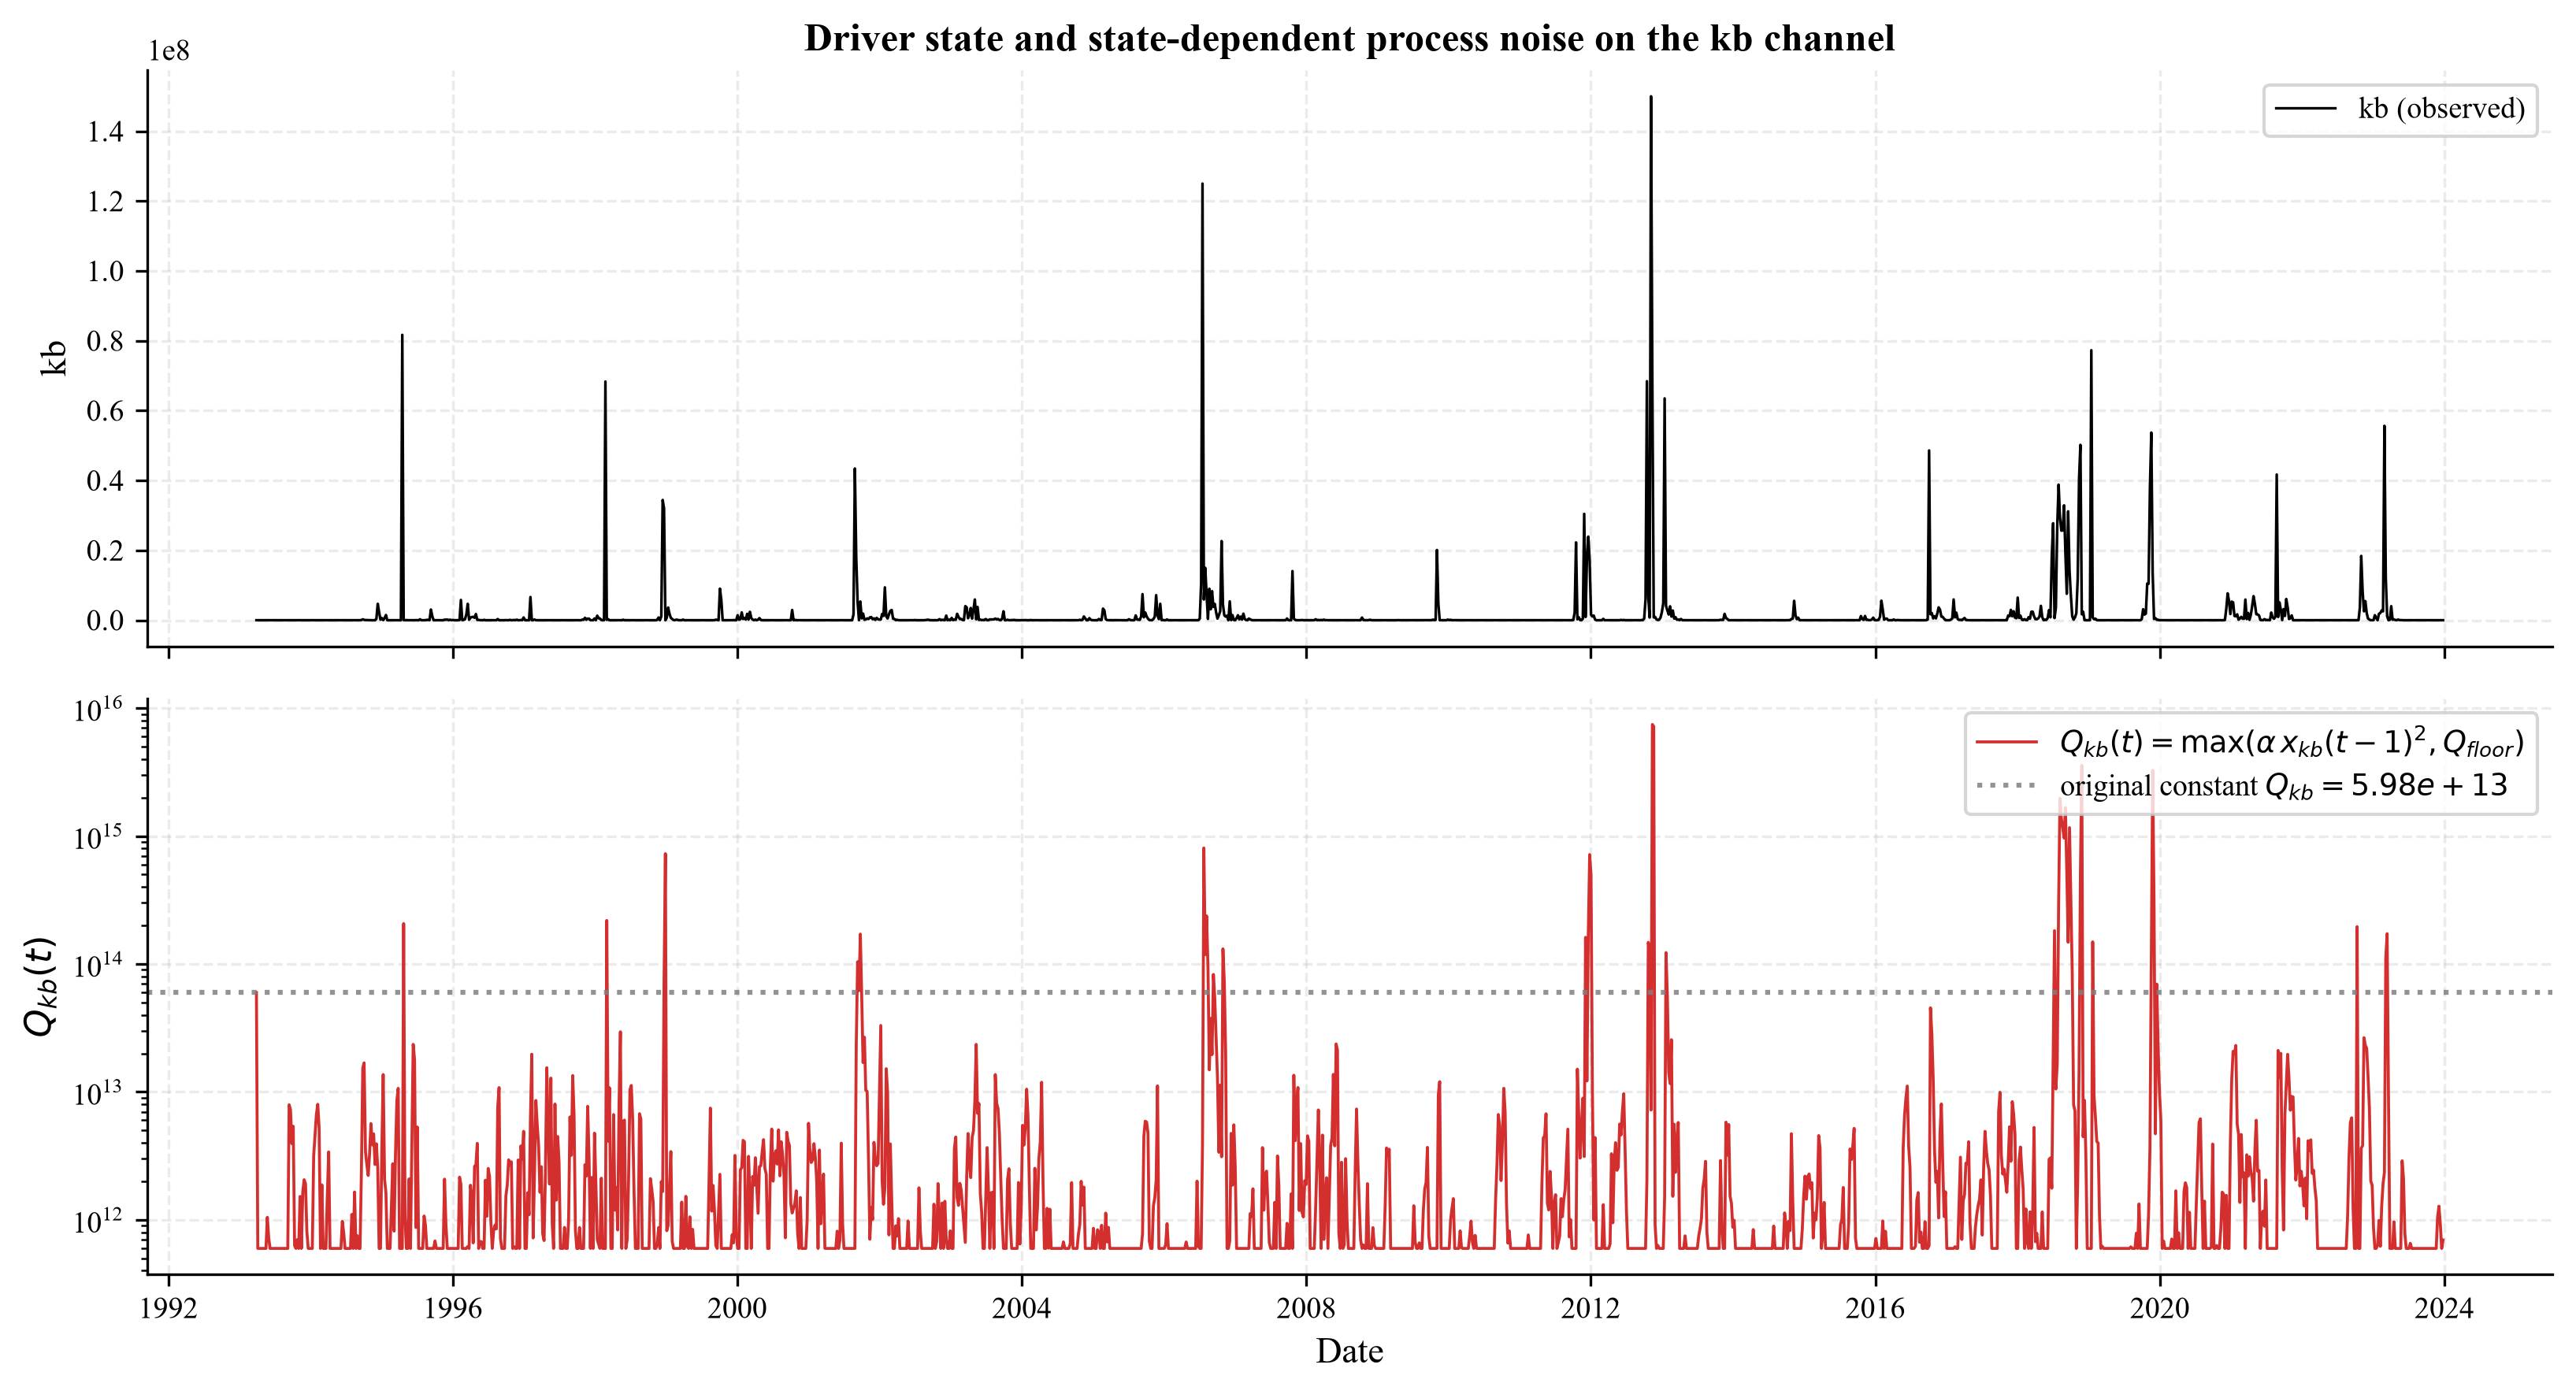


Final calibrated alpha_kb: 1.5941e+00
Q_kb(t) range : [5.9782e+11, 7.4450e+15]
Q_kb(t) median: 6.4669e+11
Original const Q_kb: 5.9782e+13


In [13]:
# Time series of Q_kb(t) versus the kb driver state
dates_full = full_df.index
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax = axes[0]
ax.plot(dates_full, observations[:, KB_IDX], color="black", lw=0.8,
        label=f"{state_vars[KB_IDX]} (observed)")
ax.set_ylabel(f"{state_vars[KB_IDX]}")
ax.set_title("Driver state and state-dependent process noise on the kb channel",
             fontweight="bold")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(frameon=True, loc="upper right")

ax = axes[1]
ax.plot(dates_full, result_sd["Q_kb_track"], color="#D32F2F", lw=0.9,
        label=r"$Q_{kb}(t) = \max(\alpha\, x_{kb}(t-1)^2, Q_{floor})$")
ax.axhline(Q_diag[KB_IDX], color="gray", linestyle=":", alpha=0.85,
           label=f"original constant $Q_{{kb}} = {Q_diag[KB_IDX]:.2e}$")
ax.set_yscale("log")
ax.set_ylabel(r"$Q_{kb}(t)$")
ax.set_xlabel("Date")
ax.legend(frameon=True, loc="upper right")
ax.grid(alpha=0.25, linestyle="--")
plt.tight_layout()
savefig(fig, "Fig4f_state_dependent_Q_kb_timeseries")
plt.show()

print(f"\nFinal calibrated alpha_kb: {alpha_kb:.4e}")
print(f"Q_kb(t) range : [{result_sd['Q_kb_track'].min():.4e}, "
      f"{result_sd['Q_kb_track'].max():.4e}]")
print(f"Q_kb(t) median: {np.median(result_sd['Q_kb_track']):.4e}")
print(f"Original const Q_kb: {Q_diag[KB_IDX]:.4e}")


## Persist diagnostics for notebook 04b

The ensemble member trajectories produced here are the input that notebook 04b
needs to run MC dropout per-member and produce the 3-D variance decomposition.
We also save the per-step gains/innovations for any future paper-ready figures.

In [14]:
ENKF_DIAGNOSTICS_PATH = os.path.join(INTERMEDIATE_DIR, "enkf_diagnostics.npz")
np.savez(
    ENKF_DIAGNOSTICS_PATH,
    # Constant-Q EnKF (baseline) — still consumed by notebook 04b
    members=result["members"].astype(np.float32),
    x_forecast_mean=result["x_forecast_mean"].astype(np.float32),
    x_analysis_mean=result["x_analysis_mean"].astype(np.float32),
    innovations_background=result["innovations_background"].astype(np.float32),
    innovations_analysis=result["innovations_analysis"].astype(np.float32),
    kalman_gain_diag=result["kalman_gain_diag"].astype(np.float32),
    P_forecast_diag=result["P_forecast_diag"].astype(np.float32),
    P_analysis_diag=result["P_analysis_diag"].astype(np.float32),
    obs_used_mask=result["obs_used_mask"],
    state_vars=np.array(state_vars),
    propagator=np.array(propagator_name),
    diagnostic_index=np.array(full_df.index.astype(str)),
    Q_diag=Q_diag.astype(np.float32),
    Q_matrix=Q_matrix.astype(np.float32),
    R_diag=R_diag.astype(np.float32),
    n_train=np.int64(n_train),
    n_val=np.int64(n_val),
    n_test=np.int64(n_test),
)
print(f"Saved EnKF diagnostics ({propagator_name}) -> {ENKF_DIAGNOSTICS_PATH}")
print(f"  ensemble members shape: {result['members'].shape}  (n_enkf, T, n_drivers)")

# Fully-calibrated variant: state-dependent Q on kb + per-channel Q/R inflation
ENKF_DIAGNOSTICS_SD_PATH = os.path.join(INTERMEDIATE_DIR, "enkf_diagnostics_state_dep_Q.npz")
np.savez(
    ENKF_DIAGNOSTICS_SD_PATH,
    members=result_sd["members"].astype(np.float32),
    x_forecast_mean=result_sd["x_forecast_mean"].astype(np.float32),
    x_analysis_mean=result_sd["x_analysis_mean"].astype(np.float32),
    innovations_background=result_sd["innovations_background"].astype(np.float32),
    innovations_analysis=result_sd["innovations_analysis"].astype(np.float32),
    kalman_gain_diag=result_sd["kalman_gain_diag"].astype(np.float32),
    P_forecast_diag=result_sd["P_forecast_diag"].astype(np.float32),
    P_analysis_diag=result_sd["P_analysis_diag"].astype(np.float32),
    obs_used_mask=result_sd["obs_used_mask"],
    Q_kb_track=result_sd["Q_kb_track"].astype(np.float32),
    R_eff=result_sd["R_eff"].astype(np.float32),
    state_vars=np.array(state_vars),
    propagator=np.array(f"{propagator_name}+state_dependent_Q_diagnostic"),
    diagnostic_index=np.array(full_df.index.astype(str)),
    Q_base_diag=Q_diag.astype(np.float32),
    Q_base_matrix=Q_matrix.astype(np.float32),
    R_base_diag=R_diag.astype(np.float32),
    Q_inflation=Q_inflation.astype(np.float64),
    R_inflation=R_inflation.astype(np.float64),
    kb_idx=np.int64(KB_IDX),
    alpha_kb=np.float64(alpha_kb),
    Q_kb_floor=np.float64(Q_kb_floor),
    n_train=np.int64(n_train),
    n_val=np.int64(n_val),
    n_test=np.int64(n_test),
)
print(f"Saved exploratory calibrated EnKF diagnostics  -> {ENKF_DIAGNOSTICS_SD_PATH}")
print(f"  alpha_kb (kb state-dep)  : {alpha_kb:.4e}")
print(f"  Q_inflation (non-kb)     : "
      + ", ".join(f"{state_vars[j]}={Q_inflation[j]:.3f}"
                  for j in range(n_drivers) if j != KB_IDX))
print(f"  R_inflation (all chans)  : "
      + ", ".join(f"{state_vars[j]}={R_inflation[j]:.3f}"
                  for j in range(n_drivers)))
print(f"\nRun notebook 04b next to consume members[] and produce the 3-D MC-dropout tensor.")


Saved EnKF diagnostics (SeasonalAR1) -> output_refactored/intermediate\enkf_diagnostics.npz
  ensemble members shape: (50, 1605, 6)  (n_enkf, T, n_drivers)
Saved exploratory calibrated EnKF diagnostics  -> output_refactored/intermediate\enkf_diagnostics_state_dep_Q.npz
  alpha_kb (kb state-dep)  : 1.5941e+00
  Q_inflation (non-kb)     : peace_discharge=1.029, peace_TN=0.425, peace_TP=0.525, wind_u=0.930, wind_v=0.890
  R_inflation (all chans)  : peace_discharge=1.251, peace_TN=0.475, peace_TP=0.622, kb=28.056, wind_u=1.172, wind_v=1.130

Run notebook 04b next to consume members[] and produce the 3-D MC-dropout tensor.
